# NICE: Non-linear Independent Components Estimation

**Authors:** Laurent Dinh, David Krueger, Yoshua Bengio (Université de Montréal)
**Venue:** ICLR 2015 (Workshop Track)

---

## Abstract

The paper introduces Non-linear Independent Component Estimation (NICE), a deep learning framework for modeling complex, high-dimensional densities. NICE learns a non-linear, deterministic, invertible transformation that maps data to a latent space in which the components are independent, so the transformed data follow a factorized distribution. The transformation is built by composing simple building blocks called coupling layers, each containing an arbitrary deep neural network. The design makes the Jacobian determinant and the inverse trivial to compute. As a result, the model can be trained by maximizing the exact log-likelihood, and unbiased ancestral sampling is straightforward. Experiments on four image datasets show competitive log-likelihoods and demonstrate that the model can perform inpainting.

---

## Problems

- **Intractable likelihoods in deep generative models:** Undirected models such as Deep Boltzmann Machines (DBMs) have intractable log-likelihoods. They require Markov chain Monte Carlo (MCMC) for training and sampling, and these chains mix slowly when the target distribution has sharp modes. Likelihood estimates obtained with annealed importance sampling (AIS) may be overly optimistic.
- **Approximate training objectives:** Variational auto-encoders (VAEs) optimize a variational lower bound rather than the true log-likelihood. This can lead to suboptimal solutions and inject unstructured noise into generated samples.
- **Expensive sampling in autoregressive models:** Models such as NADE give tractable densities, but they generate one element at a time. This makes sampling sequential, slow, and impossible to parallelize for high-dimensional data such as images.
- **Restrictive invertible transformations:** Earlier approaches either constrain the transformation family severely (orthogonal transforms in ICA, which need costly orthogonalization), lack a tractable inverse or Jacobian (general neural networks), or are trained greedily without a tractable sampling procedure (Gaussianization).

---

## Proposed Solutions

- **Change-of-variables density modeling:** Learn an invertible map $$h = f(x)$$ with $$\dim(h) = \dim(x)$$, and evaluate the data density exactly as

$$p_X(x) = p_H(f(x)) \left| \det \frac{\partial f(x)}{\partial x} \right|$$

- **Factorized prior:** Choose a prior whose dimensions are independent, so the training criterion becomes

$$\log p_X(x) = \sum_{d=1}^{D} \log p_{H_d}(f_d(x)) + \log \left| \det \frac{\partial f(x)}{\partial x} \right|$$

- **Coupling layers:** Partition the input into two blocks $$(x_{I_1}, x_{I_2})$$ and apply

$$y_{I_1} = x_{I_1}, \qquad y_{I_2} = g\big(x_{I_2};\, m(x_{I_1})\big)$$

  where $$m$$ is an arbitrarily complex function (a deep ReLU network) and $$g$$ is a coupling law that is invertible in its first argument. The Jacobian is lower triangular, so its determinant depends only on $$\partial y_{I_2} / \partial x_{I_2}$$.

- **Additive coupling:** The authors choose $$g(a; b) = a + b$$, which gives

$$y_{I_2} = x_{I_2} + m(x_{I_1}), \qquad x_{I_2} = y_{I_2} - m(y_{I_1})$$

  This layer has a unit Jacobian determinant, and its inverse costs exactly as much as the forward pass. It was chosen over multiplicative or affine coupling laws for numerical stability, because the transformation is piecewise linear when $$m$$ is a rectified network.

- **Diagonal rescaling:** Compositions of additive coupling layers preserve volume, so the authors add a final diagonal scaling layer $$S$$. The criterion then becomes

$$\log p_X(x) = \sum_{i=1}^{D} \left[ \log p_{H_i}(f_i(x)) + \log |S_{ii}| \right]$$

---

## Purpose

- Build a generative model in which exact log-likelihood training, exact inference, and efficient unbiased sampling are all tractable at once.
- Pursue the view that a good representation is one in which the data distribution is easy to model, which here means a factorized distribution with independent latent components.
- Design a family of bijections that is highly expressive yet has an easy Jacobian determinant and an easy inverse, without constraining the internal architecture of the neural networks used.

---

## Methodology

### Architecture

- **Composition:** $$f = f_L \circ \cdots \circ f_2 \circ f_1$$. The Jacobian determinant of $$f$$ is the product of the determinants of its layers.
- **Alternating partitions:** Successive coupling layers swap the roles of the two subsets so that every dimension gets transformed. At least three coupling layers are needed for all dimensions to influence one another; the experiments use four.
- **Partition scheme:** Odd-indexed dimensions ($$I_1$$) and even-indexed dimensions ($$I_2$$).
- **Final scaling:** $$h = \exp(s) \odot h^{(4)}$$, which keeps the scale positive through an exponential parametrization.

### Interpretation of the Scaling Layer

- The scaling factors play a role analogous to the PCA eigenspectrum. The quantity $$\sigma_d = S_{dd}^{-1}$$ acts as the scale of each independent component, and large $$\sigma_d$$ marks a dimension along which the model places more variation.
- The prior term pushes $$S_{ii}$$ to be small, while the term $$\log |S_{ii}|$$ prevents $$S_{ii}$$ from collapsing to zero.

### Prior Distributions

- Standard Gaussian prior:

$$\log p_{H_d}(h_d) = -\tfrac{1}{2}\left(h_d^2 + \log 2\pi\right)$$

- Standard logistic prior, which the authors prefer because its gradients are better behaved:

$$\log p_{H_d}(h_d) = -\log\left(1 + e^{h_d}\right) - \log\left(1 + e^{-h_d}\right)$$

### Experimental Setup

| Dataset  | Dimensions | Preprocessing         | Hidden Layers | Units per Layer | Prior    |
|----------|------------|-----------------------|---------------|-----------------|----------|
| MNIST    | 784        | None                  | 5             | 1000            | Logistic |
| TFD      | 2304       | Approximate whitening | 4             | 5000            | Gaussian |
| SVHN     | 3072       | ZCA                   | 4             | 2000            | Logistic |
| CIFAR-10 | 3072       | ZCA                   | 4             | 2000            | Logistic |

- **Dequantization:** Uniform noise of $$\tfrac{1}{256}$$ is added and the data are rescaled to $$[0, 1]^D$$. For CIFAR-10, noise of $$\tfrac{1}{128}$$ is added and the data are rescaled to $$[-1, 1]^D$$.
- **Coupling functions:** Deep rectified networks with linear output units, using the same architecture across all four coupling layers.
- **Optimization:** Adam with learning rate $$10^{-3}$$, momentum $$0.9$$, $$\beta_2 = 0.01$$, $$\lambda = 1$$, and $$\epsilon = 10^{-4}$$. The objective is $$\log p_H(h) + \sum_i s_i$$, and the best model is selected by validation log-likelihood after 1500 epochs.
- **Approximate whitening (TFD):** An affine NICE model $$z = Lx + b$$ with lower-triangular $$L$$ and a Gaussian prior, which is equivalent to fitting a Gaussian distribution.

### Inpainting Procedure

Observed pixels $$x_O$$ are clamped, and the hidden pixels $$x_H$$ are inferred by projected stochastic gradient ascent on the log-likelihood:

$$x_{H,i+1} = x_{H,i} + \alpha_i \left( \frac{\partial \log p_X\big((x_O, x_{H,i})\big)}{\partial x_{H,i}} + \epsilon \right), \qquad \epsilon \sim \mathcal{N}(0, I), \qquad \alpha_i = \frac{10}{100 + i}$$

---

## Results

### Test Log-Likelihood

| Model     | MNIST   | TFD     | SVHN     | CIFAR-10 |
|-----------|---------|---------|----------|----------|
| NICE      | 1980.50 | 5514.71 | 11496.55 | 5371.78  |
| Deep MFA* | —       | 5250    | —        | 3622     |
| GRBM      | —       | 2413    | —        | 2365     |

*Deep MFA values are variational lower bounds rather than exact log-likelihoods.

- NICE exceeds the best previously reported results on TFD and CIFAR-10.
- No fair comparison is possible on continuous MNIST, because prior work there is typically evaluated with Parzen window estimates.

### Qualitative Findings

- **Sampling:** Unbiased samples drawn by $$h \sim p_H(h)$$ and $$x = f^{-1}(h)$$ produce recognizable MNIST digits and TFD faces. SVHN and CIFAR-10 samples are noticeably less coherent.
- **Inpainting:** Although the model was not trained for this task, it gives reasonable reconstructions on MNIST across many masking patterns (top or bottom rows, odd or even pixels, left or right halves, central bands, and 75% or 90% random masks). Occasional spurious modes appear.
- **Manifold structure:** Mapping a randomly rotated 3D sphere from latent space back to data space produces smooth transitions between digits and between faces.
- **Learned spectrum:** The sorted scales $$\sigma_d$$ decay sharply on MNIST, which indicates a low-dimensional learned manifold. The decay is much flatter on TFD, SVHN, and CIFAR-10.

### Theoretical Connection

- NICE can be seen as a perfect auto-encoder pair. The reconstruction term becomes constant, leaving the prior term $$\log p_H(f(x))$$ and an entropy-like term $$\log |\det \partial f / \partial x|$$, which mirrors the KL-divergence term of the variational criterion.
- The authors show that the VAE trained with the reparametrization trick is effectively maximizing the joint log-likelihood of $$(x, \epsilon)$$ in a NICE model with two affine coupling layers and a Gaussian prior.
- A NICE model with a single coupling layer can be interpreted as a two-block version of NADE.

---

## Conclusions

- NICE provides a flexible architecture for learning highly non-linear bijections that map data to a factorized latent space, trained by directly maximizing the exact log-likelihood.
- Coupling layers give triangular Jacobians, which make determinant computation and inversion trivial while allowing arbitrarily complex neural networks inside each layer.
- The model supports efficient, parallelizable, unbiased ancestral sampling and achieves competitive log-likelihoods, surpassing prior reported results on TFD and CIFAR-10.
- Limitations include volume preservation in the additive coupling layers (only partly addressed by the diagonal scaling), weak sample quality on natural-image datasets, and the requirement that latent and data dimensions match.
- The authors propose that NICE could be trained with other inductive principles such as toroidal subspace analysis. They also suggest it could enrich variational inference, either through more expressive approximate posteriors or through richer priors.
- **Significance:** NICE established the coupling-layer design that became the foundation of normalizing flows, and it directly motivated later models such as Real NVP and Glow.

# Mathematical Content of NICE

The paper's math rests on one idea: if you transform data with an invertible function, you can compute the exact probability of the original data from the probability of the transformed data, as long as you account for how the transformation stretches or squeezes space. Everything else in the paper either makes that calculation cheap or uses its result.

## 1. Change of Variables

$$p_X(x) = p_H(f(x)) \left| \det \frac{\partial f(x)}{\partial x} \right|$$

This is the central equation. Here $$f$$ maps data $$x$$ to a latent code $$h$$ of the same dimension. The density of $$x$$ equals the density of its code under a simple distribution $$p_H$$, multiplied by a correction factor. The correction is the absolute determinant of the Jacobian (the matrix of all partial derivatives of $$f$$). It measures how much $$f$$ locally expands or shrinks volume: if $$f$$ spreads a small region of data space over a larger region of latent space, the data density there must be correspondingly higher. This formula is what lets NICE compute an exact likelihood, unlike models that rely on approximations.

## 2. Sampling by Inversion

$$h \sim p_H(h), \qquad x = f^{-1}(h)$$

To generate new data, draw a random code from the simple distribution and push it backwards through the inverse transformation. This is called ancestral sampling, and it is a form of inverse transform sampling. It requires $$f^{-1}$$ to be easy to compute, which is one of the paper's two design goals.

## 3. The NICE Criterion (Factorized Prior)

$$\log p_X(x) = \sum_{d=1}^{D} \log p_{H_d}(f_d(x)) + \log \left| \det \frac{\partial f(x)}{\partial x} \right|$$

Taking the logarithm of the change-of-variables formula turns the product into a sum. If the prior treats each latent dimension as independent ("factorial"), its log-density also splits into a sum over dimensions. This is the training objective, which is maximized directly. The two terms pull against each other. The first rewards mapping data to likely regions of the prior, which tends to shrink everything toward the center. The second, the log-determinant, penalizes such shrinking. Without it, the model could raise the likelihood arbitrarily just by contracting the data. Training by maximizing this quantity over the dataset is ordinary maximum likelihood estimation.

## 4. Composition and Triangular Jacobians

For a layered transformation $$f = f_L \circ \cdots \circ f_1$$, the Jacobian determinant of the whole is the product of the layers' determinants (by the chain rule and the multiplicative property of determinants). So it suffices to design simple layers with easy determinants.

The paper observes that triangular matrices have a determinant equal to the product of their diagonal entries, which costs almost nothing to compute. It also notes that many square matrices factor as $$M = LU$$ (lower times upper triangular), so composing triangular pieces can still be very expressive. The strategy is therefore to build layers whose Jacobians are triangular.

## 5. The Coupling Layer

Split the input dimensions into two groups, $$I_1$$ (of size $$d$$) and $$I_2$$. Then

$$y_{I_1} = x_{I_1}, \qquad y_{I_2} = g\big(x_{I_2};\, m(x_{I_1})\big)$$

The first group passes through unchanged. The second group is altered by a function $$g$$, the coupling law, whose behavior depends on the first group through a function $$m$$. Because one half is untouched, the Jacobian has a block-triangular shape:

$$\frac{\partial y}{\partial x} = \begin{bmatrix} I_d & 0 \\ \dfrac{\partial y_{I_2}}{\partial x_{I_1}} & \dfrac{\partial y_{I_2}}{\partial x_{I_2}} \end{bmatrix}$$

The top-right block is zero, so the determinant reduces to $$\det \frac{\partial y_{I_2}}{\partial x_{I_2}}$$. Crucially, the complicated block $$\frac{\partial y_{I_2}}{\partial x_{I_1}}$$, which involves $$m$$, never enters the determinant. That is why $$m$$ can be any function at all, including a large neural network, without making the determinant hard. Inversion is also easy:

$$x_{I_1} = y_{I_1}, \qquad x_{I_2} = g^{-1}\big(y_{I_2};\, m(y_{I_1})\big)$$

Since $$y_{I_1} = x_{I_1}$$, you can recompute $$m$$ exactly from the output and undo $$g$$. The network $$m$$ itself never needs to be inverted.

## 6. Additive Coupling

$$y_{I_2} = x_{I_2} + m(x_{I_1}), \qquad x_{I_2} = y_{I_2} - m(y_{I_1})$$

The paper's chosen coupling law is plain addition. Here $$\frac{\partial y_{I_2}}{\partial x_{I_2}}$$ is the identity matrix, so the determinant is exactly 1. The layer is volume-preserving: it shifts and bends space without stretching or squeezing it. The inverse is a subtraction, as cheap as the forward pass.

The paper also mentions alternatives: multiplicative coupling $$g(a; b) = a \odot b$$ (with $$b \neq 0$$) and affine coupling $$g(a; b) = a \odot b_1 + b_2$$ (with $$b_1 \neq 0$$). Addition was chosen for numerical stability. When $$m$$ is a ReLU network, the whole transformation is piecewise linear.

## 7. How Many Layers

A single coupling layer leaves half the dimensions unchanged, so layers alternate which half is modified. By examining the structure of the composed Jacobian, the authors note that at least three coupling layers are needed for every dimension to be able to influence every other dimension. They use four.

## 8. Diagonal Rescaling

Every additive layer has determinant 1, so their composition does too, and the model cannot change volume at all. To fix this, a final diagonal scaling multiplies each output by a factor $$S_{ii}$$. The Jacobian of a diagonal matrix is just that diagonal, so the objective becomes

$$\log p_X(x) = \sum_{i=1}^{D} \left[ \log p_{H_i}(f_i(x)) + \log |S_{ii}| \right]$$

In experiments the scale is parametrized as $$\exp(s)$$, which keeps it positive and makes the log-determinant simply $$\sum_i s_i$$. The two terms again balance: the prior term favors small $$S_{ii}$$ (shrinking outputs toward the center), while $$\log S_{ii}$$ prevents any factor from reaching zero.

## 9. Prior Distributions

Two standard one-dimensional densities are used for each latent coordinate. The standard Gaussian:

$$\log p_{H_d}(h_d) = -\tfrac{1}{2}\left(h_d^2 + \log 2\pi\right)$$

The standard logistic:

$$\log p_{H_d}(h_d) = -\log\left(1 + e^{h_d}\right) - \log\left(1 + e^{-h_d}\right)$$

The logistic has heavier tails than the Gaussian. Its gradient with respect to $$h_d$$ is bounded (it behaves linearly rather than quadratically far from zero), which the authors found gives better-behaved training. The paper notes the prior could also be learned rather than fixed.

## 10. Dequantization

Pixel values are discrete (256 levels), but NICE is a model for continuous densities. Fitting a continuous density to discrete points would let the likelihood grow without bound by concentrating mass on those points. Adding uniform noise of width $$\tfrac{1}{256}$$ (or $$\tfrac{1}{128}$$ for CIFAR-10 in the $$[-1, 1]$$ range) spreads each discrete value over a small interval, making the data genuinely continuous and the likelihoods meaningful.

## 11. Preprocessing: Whitening and ZCA

Whitening is a linear transformation that removes correlations between dimensions and gives each unit variance. ZCA is the particular whitening that stays as close as possible to the original data. For TFD, the authors learn an approximate whitening as a small NICE model:

$$z = Lx + b$$

with $$L$$ lower triangular and a Gaussian prior. Because $$L$$ is triangular, its determinant is the product of its diagonal. Fitting this by maximum likelihood is equivalent to fitting a multivariate Gaussian to the data.

## 12. Optimization

The objective $$\log p_H(h) + \sum_i s_i$$ is maximized with Adam, a gradient method that adapts the step size for each parameter using running averages of past gradients and their squares. The model is chosen by its validation log-likelihood, a standard guard against overfitting.

## 13. Inpainting as Constrained Optimization

To fill in missing pixels $$x_H$$ given observed pixels $$x_O$$, the authors search for the most likely completion:

$$\max_{x_H} \log p_X\big((x_O, x_H)\big)$$

They solve it with noisy gradient ascent:

$$x_{H,i+1} = x_{H,i} + \alpha_i \left( \frac{\partial \log p_X\big((x_O, x_{H,i})\big)}{\partial x_{H,i}} + \epsilon \right), \qquad \epsilon \sim \mathcal{N}(0, I), \qquad \alpha_i = \frac{10}{100 + i}$$

Each step nudges the missing pixels toward higher probability. The Gaussian noise helps escape poor local optima. The decreasing step size $$\alpha_i$$ makes the steps shrink over time, a standard schedule for stochastic optimization. "Projected" means values are clipped back into the valid pixel range after each step. This is an approximate maximum a posteriori (MAP) estimate. It is only possible because the exact likelihood and its gradient are available.

## 14. The Learned Spectrum

Combining the prior with the scaling layer, each latent dimension effectively has its own scale

$$\sigma_d = S_{dd}^{-1}$$

Large $$\sigma_d$$ means the model allows lots of variation along that direction; small $$\sigma_d$$ means the data barely vary there. Sorting these values is the non-linear analog of a PCA eigenvalue plot. A sharp drop (as on MNIST) indicates that the data concentrate near a lower-dimensional manifold. If some $$S_{ii}$$ grows without bound, that dimension is effectively removed, reducing the data's effective dimensionality by one.

## 15. Manifold Visualization

The authors take a 3D sphere $$S$$ in latent space, rotate it randomly with $$R$$, and map it to data space as $$f^{-1}(R(S))$$. Because $$f^{-1}$$ is smooth, nearby points on the sphere become similar images, revealing the geometry the model has learned.

## 16. The VAE as a Special Case of NICE

In Appendix C, the paper shows that the variational auto-encoder (VAE) trained with the reparametrization trick fits into the NICE framework. The VAE's recognition network produces $$z = g_\phi(\epsilon \mid x)$$ from noise $$\epsilon \sim \mathcal{N}(0, I)$$. Defining the standardized reconstruction error

$$\xi = \frac{x - f_\theta(z)}{\sigma}$$

and placing a standard Gaussian prior on $$h = (z, \xi)$$, the map from $$(x, \epsilon)$$ to $$h$$ is invertible. Its log-likelihood is

$$\log p(x, \epsilon) = \log p_H(h) - D_X \log \sigma + \log \left| \det \frac{\partial g_\phi}{\partial \epsilon}(\epsilon; x) \right|$$

where $$D_X \log \sigma$$ comes from the rescaling by $$\sigma$$ in each of the $$D_X$$ data dimensions. Subtracting $$\log p(\epsilon)$$ and applying change of variables to the recognition network turns the determinant term into $$-\log q_{Z|X}(z)$$. After rearranging, the expression becomes

$$\log p_{X|Z}(x \mid z) + \log p_Z(z) - \log q_{Z|X}(z)$$

which is exactly the single-sample Monte Carlo estimate of the VAE's training objective (the evidence lower bound). So the VAE is effectively maximizing an exact likelihood, but on the pair $$(x, \epsilon)$$ rather than on $$x$$ alone. The paper also reads the NICE objective in VAE terms: since $$f$$ and $$f^{-1}$$ reconstruct perfectly, the reconstruction term is constant. What remains is $$\log p_H(f(x))$$, which plays the role of the prior term, and the log-determinant, which plays the role of the entropy term.

## 17. Evaluation and Statistical Caveats

Results are reported as test log-likelihoods, which are higher-is-better and, for NICE, exact. The paper is careful about comparison. Deep mixtures of factor analysers report only a lower bound on log-likelihood. Annealed importance sampling, used for Boltzmann machines, can give overly optimistic estimates. Importance-sampling estimates for VAEs are not optimistic in expectation. Parzen window estimates, the usual metric on continuous MNIST, are not comparable to exact likelihoods, so the authors make no MNIST comparison. Being able to report an exact number is itself one of the paper's selling points.

## 18. Related Statistical Models

- **NADE and autoregressive models** use the probability chain rule, $$p(x) = \prod_d p(x_d \mid x_{<d})$$. Their dependency structure is also triangular, which is why their likelihood is tractable. A single NICE coupling layer can be viewed as a two-block version of this idea. Autoregressive sampling is sequential, whereas NICE samples all dimensions in parallel.
- **ICA** (independent component analysis), from which NICE takes its name, also seeks a transformation that makes components independent, but only a linear (orthogonal) one. NICE generalizes it to non-linear transformations.

# Research Gaps and Proposed Solutions in NICE

| # | Problem / Research Gap | Limitation in Prior Work | Proposed Solution in NICE |
|---|------------------------|--------------------------|---------------------------|
| 1 | **Intractable likelihood in undirected models** | Deep Boltzmann Machines have an intractable partition function. Their log-likelihood can only be estimated, for example with annealed importance sampling (AIS), which may be overly optimistic. | An invertible mapping combined with the change-of-variables formula gives an exact, tractable log-likelihood: $\log p_X(x) = \log p_H(f(x)) + \log \lvert \det \partial f / \partial x \rvert$. |
| 2 | **Slow, MCMC-dependent training and sampling** | Undirected models need Markov chain Monte Carlo for both learning and generation. The chains mix slowly when the target distribution has sharp modes. | Training is direct maximum likelihood with no sampling apart from dequantization. Generation is exact ancestral sampling: $h \sim p_H(h)$, $x = f^{-1}(h)$. |
| 3 | **Approximate objectives in variational models** | VAEs optimize a variational lower bound with a stochastic encoder and an imperfect decoder. This can produce solutions that are suboptimal for the true likelihood and add unstructured noise to samples. | A deterministic encoder $f$ and an exact decoder $f^{-1}$ form a perfect auto-encoder pair. The reconstruction term becomes constant, and the model optimizes the exact likelihood rather than a bound. |
| 4 | **Sequential sampling in autoregressive models** | NADE-style models have tractable densities but generate one dimension at a time. Sampling is computationally expensive and cannot be parallelized for high-dimensional data such as images. | Coupling layers transform blocks of dimensions at once, so both density evaluation and sampling are parallel across dimensions. A single coupling layer is equivalent to a two-block NADE. |
| 5 | **Costly Jacobian determinant for general bijections** | For an arbitrary invertible neural network, computing $\det \partial f / \partial x$ costs $O(D^3)$, which is impractical in high dimensions. | Coupling layers produce triangular Jacobians, whose determinant is the product of the diagonal entries. Additive coupling gives a determinant of exactly 1. |
| 6 | **Restricted expressiveness of tractable transformations** | ICA learns only orthogonal linear transformations and needs costly orthogonalization. Triangular weight matrices with bijective activations severely constrain the architecture. | The coupling function $m$ can be an arbitrarily complex neural network (deep ReLU MLPs) without affecting invertibility or the cost of the determinant. Expressiveness comes from stacking layers. |
| 7 | **Lack of an efficient inverse** | Gaussianization learns layered transformations greedily and lacks a tractable sampling procedure. Rippel and Adams (2013) lacked a bijectivity constraint and had to use a regularized auto-encoder proxy. | Additive coupling is inverted in closed form: $x_{I_2} = y_{I_2} - m(y_{I_1})$. The inverse costs the same as the forward pass, and $m$ itself never needs to be inverted. |
| 8 | **Partial transformation by a single layer** | One coupling layer leaves part of the input unchanged, so it cannot model dependencies between all dimensions. | The roles of the two partitions alternate across layers. At least three layers are needed for full mixing of all dimensions; four are used in the experiments. |
| 9 | **Volume preservation of additive coupling** | A composition of unit-determinant layers cannot expand or contract space, which limits density modeling. | A final diagonal scaling layer $S$ is added, contributing $\sum_i \log \lvert S_{ii} \rvert$ to the objective. It also yields an interpretable, PCA-like spectrum $\sigma_d = S_{dd}^{-1}$. |
| 10 | **Degenerate likelihoods on discrete data** | Fitting a continuous density to discrete pixel values allows the likelihood to grow without bound. | The data are dequantized by adding uniform noise ($1/256$, or $1/128$ for CIFAR-10) before training, which makes the likelihoods meaningful. |
| 11 | **Unreliable comparison between models** | Competing methods report lower bounds (Deep MFA), possibly optimistic estimates (AIS), or Parzen window estimates, which are not directly comparable. | NICE reports exact test log-likelihoods on MNIST, TFD, SVHN, and CIFAR-10, exceeding the best previously reported bounds on TFD and CIFAR-10. |
| 12 | **Inference tasks requiring dedicated training** | Conditional tasks such as inpainting usually need models trained specifically for them, or approximate posterior inference. | The exact likelihood and its gradient allow inpainting through projected stochastic gradient ascent on $\log p_X((x_O, x_H))$, with no task-specific training. |

In [1]:
# =============================================================================
#  NICE: NON-LINEAR INDEPENDENT COMPONENTS ESTIMATION
#  (Dinh, Krueger & Bengio, ICLR 2015 workshop)
#  A simplified, educational PyTorch replication in a single notebook cell.
# =============================================================================
#
#  STEP 0 - WHAT THE PAPER ACTUALLY DOES (analysis done before writing code)
#  -------------------------------------------------------------------------
#  1. TASK TYPE
#     Unsupervised density estimation / generative modelling of images
#     (Sec. 2, Sec. 5.1). The model learns p_X(x) and is evaluated by the
#     exact test log-likelihood. Two downstream uses are shown:
#       - unbiased ancestral sampling  h ~ p_H(h), x = f^{-1}(h)   (Eq. 2, Fig. 5)
#       - inpainting by likelihood maximisation                     (Sec. 5.2, Fig. 6)
#     This is NOT a classification paper. Labels are never used for training
#     (footnote 2: "We train on unlabeled data").
#
#  2. MODEL ARCHITECTURE
#     f = S o f4 o f3 o f2 o f1, where every f_k is an ADDITIVE COUPLING LAYER
#     (Sec. 3.2, Eq. 3 / Eq. 4):
#         y_I1 = x_I1
#         y_I2 = x_I2 + m(x_I1)          inverse:  x_I2 = y_I2 - m(y_I1)
#     - I1 / I2 = odd / even components, roles alternate (Sec. 5.1 equations)
#     - m^(k) = deep rectified (ReLU) MLP with linear output units (Sec. 5.1)
#     - final diagonal scaling h = exp(s) * h^(4)                 (Sec. 3.3)
#     - factorial prior: standard logistic for MNIST               (Sec. 3.4)
#
#  3. DATA / INPUT-OUTPUT STRUCTURE
#     MNIST-like grey-scale images flattened to vectors x in [0,1]^D,
#     dequantized by adding uniform noise of 1/256 (Sec. 5.1).
#     One example = one vector. The "target" is the example itself: the model
#     maximises log p_X(x); there is no separate output label.
#
#  4. LOSS / TRAINING OBJECTIVE (one unified objective, Eq. 1 + Sec. 3.3)
#        -log p_X(x) = -[ sum_d log p_Hd(h_d) ]  -  [ sum_d s_d ]
#                       \______ prior term ____/    \_ log|det J| _/
#     There is ONE objective with TWO additive components; both are logged
#     separately (they pull in opposite directions, Sec. 3.3).
#
#  5. EVALUATION METRIC
#     Exact log-likelihood in nats per example (Fig. 3, Fig. 4).
#     We also show bits/dim, a standard re-expression of the same number.
#
#  6. "CLASSES" / PREDICTION UNITS
#     A density model has no output classes. For per-unit analysis we use the
#     digit identity 0-9 (the natural grouping of MNIST) purely as an ANALYSIS
#     label:
#       - per-digit mean log-likelihood        (how well each digit is modelled)
#       - per-digit recovery after inpainting  (Sec. 5.2: does the completed
#         image still show the right digit?)
#     The model never sees these labels during training.
# =============================================================================

import io
import math
import random
import time
import copy

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, Image as IPImage


In [2]:

# -----------------------------------------------------------------------------
# Global white plotting theme (re-applied again before the dashboard)
# -----------------------------------------------------------------------------
WHITE_THEME = {
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "axes.edgecolor": "black",
    "axes.labelcolor": "black", "axes.titlecolor": "black",
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "legend.facecolor": "white",
    "legend.edgecolor": "black", "legend.labelcolor": "black",
    "grid.color": "#cccccc",
}
plt.style.use("default")
plt.rcParams.update(WHITE_THEME)


def style_ax(ax):
    """Force white background + black text on a single axis (incl. legend)."""
    ax.set_facecolor("white")
    ax.tick_params(colors="black", which="both")
    for sp in ax.spines.values():
        sp.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    leg = ax.get_legend()
    if leg is not None:
        leg.get_frame().set_facecolor("white")
        leg.get_frame().set_edgecolor("black")
        for t in leg.get_texts():
            t.set_color("black")


def show_fig(fig):
    """Render a figure to an in-memory PNG buffer and display it inline."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight", facecolor="white")
    buf.seek(0)
    display(IPImage(data=buf.read()))
    plt.close(fig)

In [3]:

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG = 10                 # images are IMG x IMG (MNIST is 28x28; shrunk for speed)
D = IMG * IMG            # data dimensionality (paper: 784 for MNIST)
N_CLASSES = 10           # digit identities 0-9, used ONLY for analysis
DIGIT_NAMES = [str(k) for k in range(N_CLASSES)]

# Dataset sizes: large enough for stable per-digit statistics
# (~150 train / ~30 val / ~30 test images per digit), small enough that
# 5 epochs run in well under a minute on a CPU.
N_TRAIN, N_VAL, N_TEST = 1500, 300, 300

BATCH_SIZE = 32
EPOCHS = 5
N_COUPLING = 4           # paper: "a stack of four coupling layers" (Sec. 5.1)
HIDDEN = 256             # paper (MNIST): 1000 units per hidden layer -> scaled down
N_HIDDEN = 4             # paper (MNIST): 5 hidden layers -> scaled down
PRIOR = "logistic"       # paper: logistic prior for MNIST (Sec. 5.1)

# Optimiser (Sec. 5.1): "AdaM with learning rate 1e-3, momentum 0.9,
# beta2 = 0.01, lambda = 1, epsilon = 1e-4". The paper uses the early Adam
# notation, where beta2 denotes (1 - decay rate), so beta2 = 0.01 corresponds
# to PyTorch's betas[1] = 0.99. lambda = 1 means no decay schedule on beta1,
# which is PyTorch's default behaviour.
LR, BETAS, ADAM_EPS = 1e-3, (0.9, 0.99), 1e-4

INPAINT_ITERS = 300      # iterations of projected stochastic gradient ascent

print(f"Device: {device} | D = {D} | prior = {PRIOR}")

Device: cuda | D = 100 | prior = logistic


In [4]:
# =============================================================================
# 1. SYNTHETIC DATASET (mirrors the paper's MNIST setting)
# =============================================================================
# WHY THIS IS FAITHFUL
#   - The paper's MNIST model is a density model over flattened grey-scale
#     digit images with bright strokes on a black background. We render digits
#     0-9 as stroke images on a 10x10 canvas with random shift, stroke
#     thickness, per-stroke intensity and background speckle, so there is real
#     intra-class variation for the density model to capture.
#   - Pixels are stored as integers 0..255 exactly like MNIST, then dequantized
#     with uniform noise of 1/256 and rescaled to [0,1] (Sec. 5.1).
# WHAT IS SIMPLIFIED
#   - Seven-segment-style glyphs instead of handwriting, and 10x10 instead of
#     28x28, so the model trains in 5 short epochs.
#   - Digit labels are kept ONLY for analysis; training is fully unsupervised.

SEGMENTS = {0: "abcdef", 1: "bc", 2: "abged", 3: "abgcd", 4: "fgbc",
            5: "afgcd", 6: "afgedc", 7: "abc", 8: "abcdefg", 9: "abcdfg"}


def render_digit(digit, rng):
    """Draw one stroke digit as a uint8 IMG x IMG image (values 0..255)."""
    canvas = np.zeros((IMG, IMG), dtype=np.float64)
    dr, dc = rng.integers(-1, 2), rng.integers(-1, 2)   # random translation
    thick = rng.integers(1, 3)                           # stroke width 1 or 2
    r0, rm, r2 = 1 + dr, 4 + dr, 7 + dr                  # top / middle / bottom rows
    c0, c1 = 2 + dc, 6 + dc                              # left / right columns
    base = rng.uniform(170, 255)                         # overall brightness

    def hline(r, ca, cb, val):
        for t in range(thick):
            rr = r + t
            if 0 <= rr < IMG:
                a, b = max(ca, 0), min(cb + 1, IMG)
                canvas[rr, a:b] = np.maximum(canvas[rr, a:b], val)

    def vline(c, ra, rb, val):
        for t in range(thick):
            cc = c + t
            if 0 <= cc < IMG:
                a, b = max(ra, 0), min(rb + 1, IMG)
                canvas[a:b, cc] = np.maximum(canvas[a:b, cc], val)

    for seg in SEGMENTS[digit]:
        val = base * rng.uniform(0.75, 1.0)              # per-stroke intensity
        if seg == "a": hline(r0, c0, c1, val)
        if seg == "g": hline(rm, c0, c1, val)
        if seg == "d": hline(r2, c0, c1, val)
        if seg == "f": vline(c0, r0, rm, val)
        if seg == "b": vline(c1, r0, rm, val)
        if seg == "e": vline(c0, rm, r2, val)
        if seg == "c": vline(c1, rm, r2, val)

    speck = rng.random((IMG, IMG)) < 0.04                # faint background noise
    canvas[speck] = np.maximum(canvas[speck], rng.uniform(0, 60, speck.sum()))
    return np.clip(np.round(canvas), 0, 255).astype(np.uint8).reshape(-1)


def make_split(n, rng):
    labels = np.arange(n) % N_CLASSES                    # balanced digits
    rng.shuffle(labels)
    pixels = np.stack([render_digit(int(k), rng) for k in labels])
    return pixels, labels.astype(np.int64)


data_rng = np.random.default_rng(SEED)
train_pix, train_lab = make_split(N_TRAIN, data_rng)
val_pix, val_lab = make_split(N_VAL, data_rng)
test_pix, test_lab = make_split(N_TEST, data_rng)


class DequantizedDigits(Dataset):
    """
    Returns (x, digit) where x in [0,1]^D is a dequantized image.
    Sec. 5.1: "we add a uniform noise of 1/256 to the data and rescale it
    to be in [0,1]^D after dequantization", i.e. x = (pixel + u) / 256 with
    u ~ U(0,1).
      - training split: fresh noise on every access (as in the paper)
      - val/test splits: noise drawn once and fixed, so the reported
        log-likelihoods are comparable across epochs
    """

    def __init__(self, pixels, labels, fixed_noise_seed=None):
        self.pixels = torch.from_numpy(pixels).float()
        self.labels = torch.from_numpy(labels)
        self.fixed_noise = None
        if fixed_noise_seed is not None:
            g = torch.Generator().manual_seed(fixed_noise_seed)
            self.fixed_noise = torch.rand(self.pixels.shape, generator=g)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        u = self.fixed_noise[i] if self.fixed_noise is not None else torch.rand(D)
        x = (self.pixels[i] + u) / 256.0
        return x, self.labels[i]


train_ds = DequantizedDigits(train_pix, train_lab)
val_ds = DequantizedDigits(val_pix, val_lab, fixed_noise_seed=1)
test_ds = DequantizedDigits(test_pix, test_lab, fixed_noise_seed=2)

g_loader = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g_loader)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)


def ascii_img(v):
    """Turn a flattened [0,1] image into IMG lines of ASCII art."""
    chars = " .:-=+*#%@"
    arr = np.asarray(v).reshape(IMG, IMG)
    return ["".join(chars[min(int(p * len(chars)), len(chars) - 1)] for p in row)
            for row in arr]


# ---------------------------- sanity check ----------------------------------
xb, yb = next(iter(train_loader))
print("\n=== DATASET SANITY CHECK ===")
print(f"Train / Val / Test sizes : {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")
print(f"One batch x shape        : {tuple(xb.shape)}  (batch, D = {IMG}x{IMG})")
print(f"x value range            : [{xb.min():.4f}, {xb.max():.4f}]  (dequantized, in [0,1])")
print(f"Training target          : the input itself (maximise log p_X(x)); no labels used")
print(f"Analysis label range     : {int(yb.min())}..{int(yb.max())} (digit identity)")
print(f"'Class' vocabulary       : {DIGIT_NAMES}")
print(f"Train digits per class   : {np.bincount(train_lab, minlength=N_CLASSES).tolist()}")
print("Preview (digits 0, 3, 8 from the training set):")
previews = [ascii_img(train_ds[int(np.where(train_lab == k)[0][0])][0].numpy()) for k in (0, 3, 8)]
for row in zip(*previews):
    print("   " + "   |   ".join(row))




=== DATASET SANITY CHECK ===
Train / Val / Test sizes : 1500 / 300 / 300
One batch x shape        : (32, 100)  (batch, D = 10x10)
x value range            : [0.0000, 0.9414]  (dequantized, in [0,1])
Training target          : the input itself (maximise log p_X(x)); no labels used
Analysis label range     : 0..9 (digit identity)
'Class' vocabulary       : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Train digits per class   : [150, 150, 150, 150, 150, 150, 150, 150, 150, 150]
Preview (digits 0, 3, 8 from the training set):
                |                |      ##***+ 
      #****     |                |      ##***+ 
      #   *     |      ######    |      ##  ++ 
      #   *     |      ######    |      ##**** 
      #.  *     |          ##    |      ****** 
      *   *     |    . ######    |      **  ** 
      *   *.    |      ######    |      ****** 
      #####     |       .  ##    |      *****  
                |      ######    |             
                |      #####     

In [5]:
# =============================================================================
# 2. MODEL: NICE, built from first principles
# =============================================================================


class CouplingMLP(nn.Module):
    """
    Coupling function m (Sec. 3.2, Sec. 5.1): a deep rectified network with
    linear output units, mapping the conditioning half (d inputs) to the
    modified half (D - d outputs). Any function works here; invertibility of
    the coupling layer never requires inverting m.
    """

    def __init__(self, in_dim, out_dim, hidden, n_hidden):
        super().__init__()
        layers, d = [], in_dim
        for _ in range(n_hidden):
            layers += [nn.Linear(d, hidden), nn.ReLU()]
            d = hidden
        self.out = nn.Linear(d, out_dim)       # linear output units
        self.net = nn.Sequential(*layers, self.out)
        # Practical choice (not stated in the paper): start each coupling layer
        # at the identity map by zero-initialising the output layer. This keeps
        # the initial transformation well behaved.
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, x):
        return self.net(x)


class AdditiveCouplingLayer(nn.Module):
    """
    Additive coupling layer (Sec. 3.2, Eq. 3 and Eq. 4):
        forward : y_I1 = x_I1,  y_I2 = x_I2 + m(x_I1)
        inverse : x_I1 = y_I1,  x_I2 = y_I2 - m(y_I1)
    The Jacobian is block-triangular with identity diagonal blocks, so
    log|det J| = 0 for this layer: it preserves volume.

    Partition (Sec. 5.1): odd components (I1) and even components (I2).
    With the paper's 1-based indexing, "odd" = 0-based indices 0, 2, 4, ...
    `modify_even=True`  -> condition on odd, modify even  (layers 1 and 3)
    `modify_even=False` -> condition on even, modify odd  (layers 2 and 4)
    """

    def __init__(self, dim, modify_even, hidden, n_hidden):
        super().__init__()
        idx = torch.arange(dim)
        odd, even = idx[0::2], idx[1::2]
        mod, cond = (even, odd) if modify_even else (odd, even)
        self.register_buffer("mod_idx", mod)
        self.register_buffer("cond_idx", cond)
        self.m = CouplingMLP(len(cond), len(mod), hidden, n_hidden)

    def forward(self, x):                                   # Eq. 3
        y = x.clone()
        y[:, self.mod_idx] = x[:, self.mod_idx] + self.m(x[:, self.cond_idx])
        return y

    def inverse(self, y):                                   # Eq. 4
        x = y.clone()
        x[:, self.mod_idx] = y[:, self.mod_idx] - self.m(y[:, self.cond_idx])
        return x


class NICE(nn.Module):
    """
    Full NICE model (Sec. 5.1 equations):
        h1_I1 = x_I1           h1_I2 = x_I2  + m1(x_I1)
        h2_I2 = h1_I2          h2_I1 = h1_I1 + m2(h1_I2)
        h3_I1 = h2_I1          h3_I2 = h2_I2 + m3(h2_I1)
        h4_I2 = h3_I2          h4_I1 = h3_I1 + m4(h3_I2)
        h     = exp(s) * h4                                  (Sec. 3.3)
    Note: the paper's text writes m2(x_I2) and m4(x_I2); for the map to be
    invertible the argument must be the CURRENT value of the unchanged half
    (h1_I2, h3_I2), which is what we implement.

    Log-likelihood (Eq. 1 with Sec. 3.3):
        log p_X(x) = sum_d log p_Hd(h_d) + sum_d s_d
    """

    def __init__(self, dim, n_coupling, hidden, n_hidden, prior="logistic"):
        super().__init__()
        self.dim, self.prior = dim, prior
        self.layers = nn.ModuleList([
            AdditiveCouplingLayer(dim, modify_even=(k % 2 == 0),
                                  hidden=hidden, n_hidden=n_hidden)
            for k in range(n_coupling)])
        # Diagonal scaling S_dd = exp(s_d), "parametrized exponentially" (Sec. 5.1)
        self.s = nn.Parameter(torch.zeros(dim))

    # ---- factorial prior p_H (Sec. 3.4) ----
    def log_prior(self, h):
        if self.prior == "logistic":
            # log p(h_d) = -log(1 + e^{h_d}) - log(1 + e^{-h_d})
            return -(F.softplus(h) + F.softplus(-h)).sum(dim=1)
        # Gaussian: log p(h_d) = -0.5 (h_d^2 + log 2*pi)
        return (-0.5 * (h ** 2 + math.log(2 * math.pi))).sum(dim=1)

    # ---- encoder f (inference, Fig. 1a) ----
    def forward(self, x):
        h = x
        for layer in self.layers:
            h = layer(h)
        h = h * torch.exp(self.s)                          # scaling layer
        log_prior = self.log_prior(h)                      # sum_d log p_Hd(h_d)
        # Only the scaling layer changes volume; each coupling layer has unit
        # Jacobian determinant. log|det J| = sum_d s_d, the same for every x.
        log_det = self.s.sum().expand(x.shape[0])
        return h, log_prior, log_det

    def log_likelihood(self, x):
        _, lp, ld = self.forward(x)
        return lp + ld

    # ---- decoder f^{-1} (sampling, Fig. 1b) ----
    def inverse(self, h):
        x = h * torch.exp(-self.s)
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x

    def sample_prior(self, n):
        if self.prior == "logistic":                       # inverse-CDF sampling
            u = torch.rand(n, self.dim, device=self.s.device).clamp(1e-6, 1 - 1e-6)
            return torch.log(u) - torch.log1p(-u)
        return torch.randn(n, self.dim, device=self.s.device)

    @torch.no_grad()
    def sample(self, n):                                   # Eq. 2
        return self.inverse(self.sample_prior(n))


model = NICE(D, N_COUPLING, HIDDEN, N_HIDDEN, PRIOR).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nNICE model: {N_COUPLING} additive coupling layers, m = ReLU MLP "
      f"({N_HIDDEN} x {HIDDEN}), trainable parameters = {n_params:,}")

# Invertibility sanity check: f^{-1}(f(x)) should reproduce x up to float error.
# We temporarily perturb the zero-initialised output layers so the check is
# not trivially an identity map.
with torch.no_grad():
    test_model = copy.deepcopy(model)
    for layer in test_model.layers:
        nn.init.normal_(layer.m.out.weight, std=0.1)
    xs = xb[:8].to(device)
    rec = test_model.inverse(test_model(xs)[0])
    print(f"Invertibility check |f^-1(f(x)) - x|_max = {(rec - xs).abs().max().item():.2e}")
    del test_model



NICE model: 4 additive coupling layers, m = ReLU MLP (4 x 256), trainable parameters = 893,228
Invertibility check |f^-1(f(x)) - x|_max = 1.19e-07


In [6]:

# =============================================================================
# 3. TRAINING (exact maximum likelihood, Sec. 5.1)
# =============================================================================


def bits_per_dim(ll_nats):
    """
    Re-express a continuous log-likelihood on [0,1]^D (nats) as bits per
    dimension of the discrete 256-level data: each pixel bin has width 1/256,
    so log P(discrete) ~= log p(x) - D log 256.
    """
    return (-ll_nats + D * math.log(256)) / (D * math.log(2))


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    lls, lps, lds, labs = [], [], [], []
    for x, y in loader:
        x = x.to(device)
        _, lp, ld = model(x)
        lls.append((lp + ld).cpu()); lps.append(lp.cpu()); lds.append(ld.cpu()); labs.append(y)
    ll = torch.cat(lls).numpy(); lp = torch.cat(lps).numpy()
    ld = torch.cat(lds).numpy(); lab = torch.cat(labs).numpy()
    per_class = np.array([ll[lab == k].mean() if np.any(lab == k) else np.nan
                          for k in range(N_CLASSES)])
    return {"ll": float(ll.mean()), "nll": float(-ll.mean()),
            "prior": float(-lp.mean()), "logdet": float(-ld.mean()),
            "bpd": bits_per_dim(float(ll.mean())),
            "per_class_ll": per_class, "ll_all": ll, "labels": lab}


optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=BETAS, eps=ADAM_EPS)

history = {k: [] for k in ["train_nll", "val_nll", "train_prior", "val_prior",
                           "train_logdet", "val_logdet", "train_ll", "val_ll",
                           "train_bpd", "val_bpd", "val_class_ll"]}
best_val_ll, best_epoch, best_state = -float("inf"), 0, None

print("\n=== TRAINING (5 epochs, objective = exact negative log-likelihood) ===")
for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    n_seen, s_nll, s_prior, s_logdet, s_ll = 0, 0.0, 0.0, 0.0, 0.0
    for x, _ in train_loader:                  # labels ignored: unsupervised
        x = x.to(device)
        h, lp, ld = model(x)
        ll = lp + ld                           # log p_X(x)
        loss = -ll.mean()                      # minimise NLL = maximise likelihood
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x.shape[0]
        n_seen += bs
        s_nll += loss.item() * bs
        s_prior += (-lp).sum().item()          # component 1: -log p_H(f(x))
        s_logdet += (-ld).sum().item()         # component 2: -log|det df/dx|
        s_ll += ll.sum().item()

    # Training metrics are running averages over the epoch (weights change
    # during the epoch); validation metrics use the end-of-epoch weights.
    tr_ll = s_ll / n_seen
    history["train_nll"].append(s_nll / n_seen)
    history["train_prior"].append(s_prior / n_seen)
    history["train_logdet"].append(s_logdet / n_seen)
    history["train_ll"].append(tr_ll)
    history["train_bpd"].append(bits_per_dim(tr_ll))

    val = evaluate(model, val_loader)
    history["val_nll"].append(val["nll"]); history["val_prior"].append(val["prior"])
    history["val_logdet"].append(val["logdet"]); history["val_ll"].append(val["ll"])
    history["val_bpd"].append(val["bpd"]); history["val_class_ll"].append(val["per_class_ll"])

    # Model selection by validation log-likelihood (Sec. 5.1)
    if val["ll"] > best_val_ll:
        best_val_ll, best_epoch = val["ll"], epoch
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch}/{EPOCHS} | train NLL {history['train_nll'][-1]:9.2f} "
          f"(prior {history['train_prior'][-1]:8.2f}, logdet {history['train_logdet'][-1]:8.2f}) | "
          f"val LL {val['ll']:8.2f} nats, {val['bpd']:.3f} bits/dim | {time.time() - t0:.1f}s")

model.load_state_dict(best_state)
print(f"\nLoaded best model from epoch {best_epoch} (val log-likelihood {best_val_ll:.2f} nats)")




=== TRAINING (5 epochs, objective = exact negative log-likelihood) ===
Epoch 1/5 | train NLL    138.48 (prior   140.77, logdet    -2.30) | val LL  -135.54 nats, 9.955 bits/dim | 0.8s
Epoch 2/5 | train NLL    132.95 (prior   139.97, logdet    -7.03) | val LL  -130.32 nats, 9.880 bits/dim | 0.4s
Epoch 3/5 | train NLL    127.94 (prior   139.70, logdet   -11.76) | val LL  -125.42 nats, 9.809 bits/dim | 0.4s
Epoch 4/5 | train NLL    123.05 (prior   139.54, logdet   -16.49) | val LL  -120.59 nats, 9.740 bits/dim | 0.4s
Epoch 5/5 | train NLL    118.24 (prior   139.46, logdet   -21.22) | val LL  -115.77 nats, 9.670 bits/dim | 0.4s

Loaded best model from epoch 5 (val log-likelihood -115.77 nats)


In [7]:
# =============================================================================
# 4. EVALUATION + PREDICTION PIPELINES
# =============================================================================

# ---- 4a. Exact test log-likelihood (the paper's headline metric, Fig. 3) ----
test_eval = evaluate(model, test_loader)
print("\n=== TEST LOG-LIKELIHOOD (exact, as in Fig. 3) ===")
print(f"Test log-likelihood : {test_eval['ll']:.2f} nats per image "
      f"({test_eval['bpd']:.3f} bits/dim)")
for k in range(N_CLASSES):
    print(f"  digit {k}: mean log-likelihood {test_eval['per_class_ll'][k]:8.2f} nats")

# ---- 4b. Unbiased ancestral sampling (Eq. 2, Fig. 5) ----
model.eval()
torch.manual_seed(SEED)
samples = model.sample(64).clamp(0, 1).cpu().numpy()

# ---- 4c. Inpainting by projected stochastic gradient ascent (Sec. 5.2) ----
MASK_TYPES = ["top rows", "bottom rows", "odd pixels", "even pixels", "left side",
              "right side", "middle vertically", "middle horizontally",
              "75% random", "90% random"]     # the ten masks listed in Fig. 6


def make_mask(kind, rng):
    """Boolean mask over D pixels; True = hidden (to be inpainted)."""
    grid = np.zeros((IMG, IMG), dtype=bool)
    half = IMG // 2
    if kind == "top rows":              grid[:half, :] = True
    elif kind == "bottom rows":         grid[half:, :] = True
    elif kind == "odd pixels":          grid.reshape(-1)[0::2] = True
    elif kind == "even pixels":         grid.reshape(-1)[1::2] = True
    elif kind == "left side":           grid[:, :half] = True
    elif kind == "right side":          grid[:, half:] = True
    elif kind == "middle vertically":   grid[:, 3:7] = True
    elif kind == "middle horizontally": grid[3:7, :] = True
    elif kind == "75% random":          grid = rng.random((IMG, IMG)) < 0.75
    elif kind == "90% random":          grid = rng.random((IMG, IMG)) < 0.90
    return grid.reshape(-1)


def inpaint(model, x_true, mask, n_iter):
    """
    Sec. 5.2: clamp the observed pixels x_O and maximise log p_X((x_O, x_H))
    over the hidden pixels x_H:
        x_H <- x_H + alpha_i * ( d log p_X / d x_H + eps ),  eps ~ N(0, I)
        alpha_i = 10 / (100 + i)
    followed by projection onto [0,1] (the original pixel range).
    The hidden pixels start from uniform noise, matching the "initial state"
    panel of Fig. 6(b).
    """
    model.eval()
    x = x_true.clone()
    x[mask] = torch.rand_like(x)[mask]
    init_state = x.clone()
    for i in range(n_iter):
        x = x.detach().requires_grad_(True)
        ll = model.log_likelihood(x).sum()
        grad, = torch.autograd.grad(ll, x)
        alpha = 10.0 / (100.0 + i)
        step = alpha * (grad + torch.randn_like(x))
        x = x.detach() + step * mask.float()          # update hidden pixels only
        x = x.clamp(0.0, 1.0)                          # projection step
        x = torch.where(mask, x, x_true)               # keep observed pixels clamped
    return init_state, x.detach()


# Digit read-out for the inpainted images. The model has no classifier, so we
# use nearest class-mean template matching (class means from the training set).
# Confidence = softmax(-squared distance / T), where T is the average squared
# distance of training images to their own class mean (a natural noise scale).
train_clean = (torch.from_numpy(train_pix).float() + 0.5) / 256.0
prototypes = torch.stack([train_clean[torch.from_numpy(train_lab) == k].mean(0)
                          for k in range(N_CLASSES)])
TEMP = ((train_clean - prototypes[torch.from_numpy(train_lab)]) ** 2).sum(1).mean()


def read_digit(x):
    d2 = ((x[:, None, :] - prototypes[None]) ** 2).sum(-1)
    probs = torch.softmax(-d2 / TEMP, dim=1)
    conf, pred = probs.max(1)
    return pred.numpy(), conf.numpy()


mask_rng = np.random.default_rng(SEED + 7)
x_test = torch.stack([test_ds[i][0] for i in range(len(test_ds))])
y_test = test_lab.copy()
mask_kind_idx = np.arange(len(test_ds)) % len(MASK_TYPES)       # cycle mask types
masks = torch.from_numpy(np.stack([make_mask(MASK_TYPES[j], mask_rng)
                                   for j in mask_kind_idx]))

torch.manual_seed(SEED + 11)
init_states, inpainted = inpaint(model, x_test.to(device), masks.to(device), INPAINT_ITERS)
init_states, inpainted = init_states.cpu(), inpainted.cpu()

pred_clean, _ = read_digit(x_test)
pred_init, _ = read_digit(init_states)
pred_inp, conf_inp = read_digit(inpainted)
correct = pred_inp == y_test
acc_clean = float((pred_clean == y_test).mean())
acc_init = float((pred_init == y_test).mean())
acc_inp = float(correct.mean())

hidden_mse = (((inpainted - x_test) ** 2) * masks.float()).sum(1) / masks.float().sum(1).clamp(min=1)
init_mse = (((init_states - x_test) ** 2) * masks.float()).sum(1) / masks.float().sum(1).clamp(min=1)
with torch.no_grad():
    ll_true = model.log_likelihood(x_test.to(device)).cpu().numpy()
    ll_inp = model.log_likelihood(inpainted.to(device)).cpu().numpy()

per_mask_acc = np.array([correct[mask_kind_idx == j].mean() for j in range(len(MASK_TYPES))])
per_mask_mse = np.array([hidden_mse[torch.from_numpy(mask_kind_idx == j)].mean().item()
                         for j in range(len(MASK_TYPES))])

cm = np.zeros((N_CLASSES, N_CLASSES))
for t, p in zip(y_test, pred_inp):
    cm[t, p] += 1
cm_norm = cm / np.clip(cm.sum(1, keepdims=True), 1, None)
per_class_inp_acc = np.diag(cm_norm)

print("\n=== INPAINTING (Sec. 5.2) ===")
print(f"Digit read-out accuracy | clean test images  : {acc_clean:.1%} (upper bound)")
print(f"                        | initial noisy state: {acc_init:.1%} (before inpainting)")
print(f"                        | after inpainting   : {acc_inp:.1%}")
print(f"Hidden-pixel MSE: initial state {init_mse.mean():.4f} -> inpainted {hidden_mse.mean():.4f}")

print("\n=== QUALITATIVE PREDICTIONS (one per mask type) ===")
print(f"{'idx':>4} | {'mask type':<19} | true | recovered | conf  | hidden MSE | "
      f"log p(true) | log p(inpainted)")
for j in range(len(MASK_TYPES)):
    i = int(np.where(mask_kind_idx == j)[0][0])
    print(f"{i:>4} | {MASK_TYPES[j]:<19} |  {y_test[i]}   |     {pred_inp[i]}     | "
          f"{conf_inp[i]:.2f}  |   {hidden_mse[i].item():.4f}   | {ll_true[i]:10.2f} | {ll_inp[i]:10.2f}")

print("\nImage view (original | initial state | inpainted), 3 examples:")
for j in (0, 4, 8):
    i = int(np.where(mask_kind_idx == j)[0][0])
    print(f"  example {i}: mask = '{MASK_TYPES[j]}', true digit = {y_test[i]}, "
          f"recovered = {pred_inp[i]}")
    panels = [ascii_img(x_test[i].numpy()), ascii_img(init_states[i].numpy()),
              ascii_img(inpainted[i].numpy())]
    for row in zip(*panels):
        print("     " + "  |  ".join(row))



=== TEST LOG-LIKELIHOOD (exact, as in Fig. 3) ===
Test log-likelihood : -115.77 nats per image (9.670 bits/dim)
  digit 0: mean log-likelihood  -115.83 nats
  digit 1: mean log-likelihood  -115.71 nats
  digit 2: mean log-likelihood  -115.97 nats
  digit 3: mean log-likelihood  -115.68 nats
  digit 4: mean log-likelihood  -116.08 nats
  digit 5: mean log-likelihood  -115.72 nats
  digit 6: mean log-likelihood  -115.74 nats
  digit 7: mean log-likelihood  -115.97 nats
  digit 8: mean log-likelihood  -115.51 nats
  digit 9: mean log-likelihood  -115.51 nats

=== INPAINTING (Sec. 5.2) ===
Digit read-out accuracy | clean test images  : 50.7% (upper bound)
                        | initial noisy state: 20.3% (before inpainting)
                        | after inpainting   : 31.7%
Hidden-pixel MSE: initial state 0.2820 -> inpainted 0.0504

=== QUALITATIVE PREDICTIONS (one per mask type) ===
 idx | mask type           | true | recovered | conf  | hidden MSE | log p(true) | log p(inpainted)
 

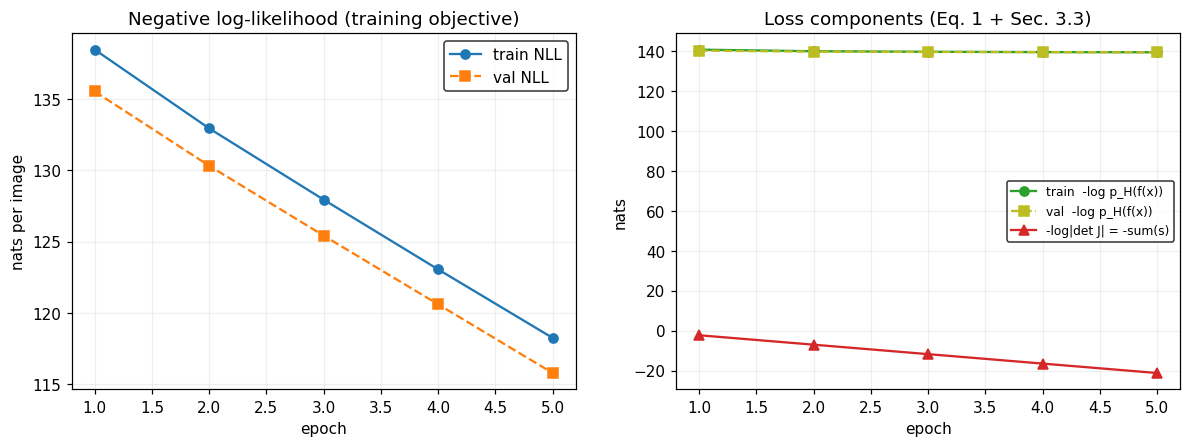

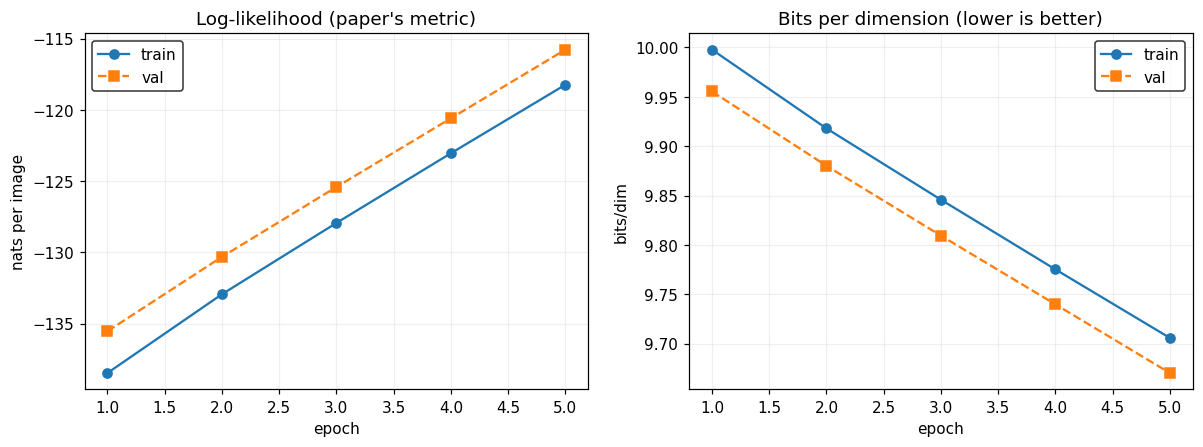

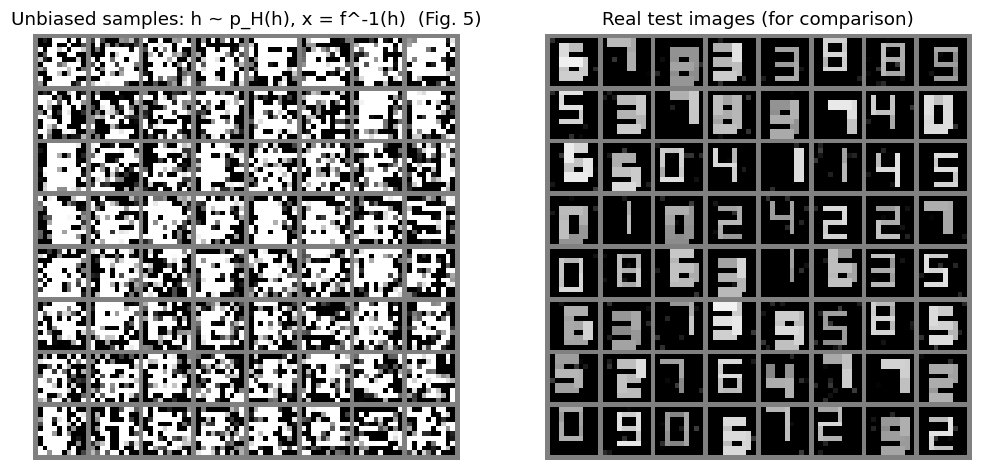

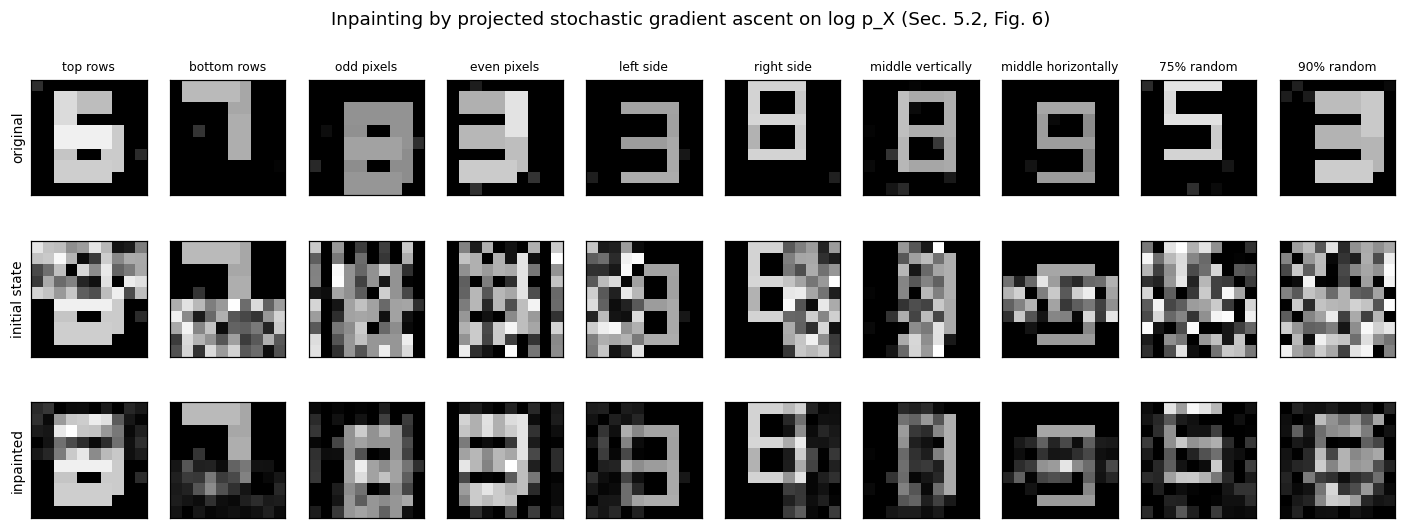

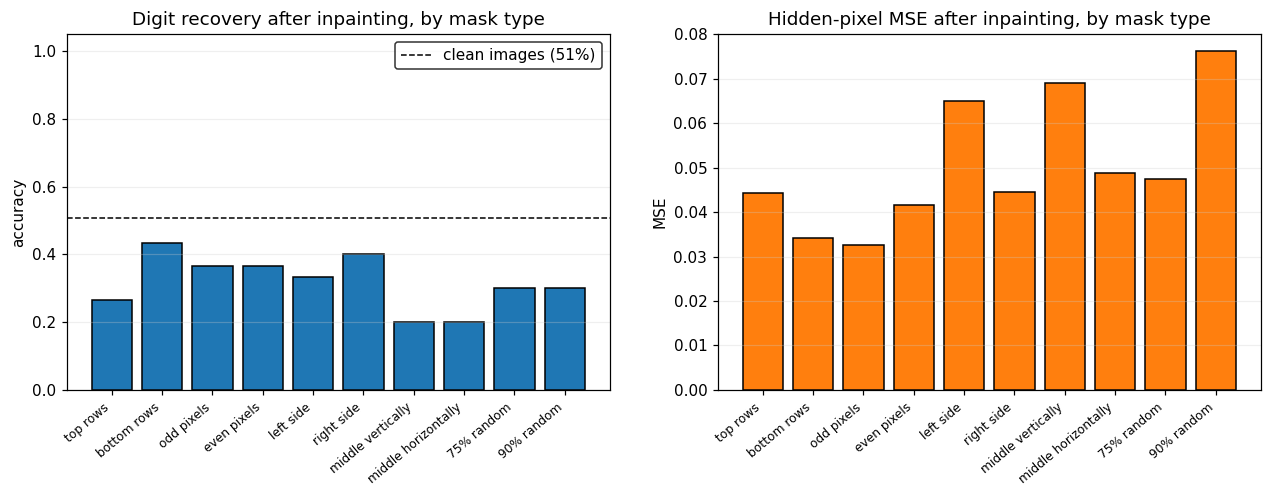

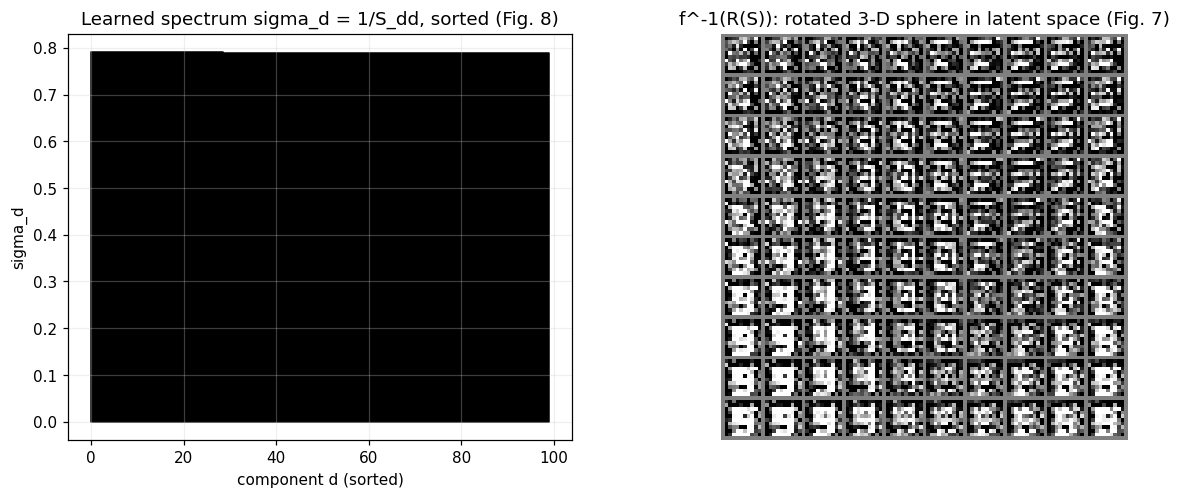

In [8]:

# =============================================================================
# 5. STANDARD EDUCATIONAL PLOTS
# =============================================================================
epochs = np.arange(1, EPOCHS + 1)


def tile(imgs, nrow, ncol, pad=1):
    """Arrange flattened images into one grid image with grey borders."""
    imgs = np.asarray(imgs).reshape(-1, IMG, IMG)
    canvas = np.full((nrow * (IMG + pad) + pad, ncol * (IMG + pad) + pad), 0.5)
    for k in range(min(len(imgs), nrow * ncol)):
        r, c = divmod(k, ncol)
        r0, c0 = pad + r * (IMG + pad), pad + c * (IMG + pad)
        canvas[r0:r0 + IMG, c0:c0 + IMG] = imgs[k]
    return canvas


# ---- 5a. Loss curves and the two loss components ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(epochs, history["train_nll"], "o-", color="tab:blue", label="train NLL")
axes[0].plot(epochs, history["val_nll"], "s--", color="tab:orange", label="val NLL")
axes[0].set(title="Negative log-likelihood (training objective)", xlabel="epoch",
            ylabel="nats per image"); axes[0].grid(alpha=.3); axes[0].legend()
axes[1].plot(epochs, history["train_prior"], "o-", color="tab:green", label="train  -log p_H(f(x))")
axes[1].plot(epochs, history["val_prior"], "s--", color="tab:olive", label="val  -log p_H(f(x))")
axes[1].plot(epochs, history["train_logdet"], "^-", color="tab:red", label="-log|det J| = -sum(s)")
axes[1].set(title="Loss components (Eq. 1 + Sec. 3.3)", xlabel="epoch", ylabel="nats")
axes[1].grid(alpha=.3); axes[1].legend(fontsize=8)
for ax in axes: style_ax(ax)
show_fig(fig)

# ---- 5b. Log-likelihood and bits/dim ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(epochs, history["train_ll"], "o-", color="tab:blue", label="train")
axes[0].plot(epochs, history["val_ll"], "s--", color="tab:orange", label="val")
axes[0].set(title="Log-likelihood (paper's metric)", xlabel="epoch", ylabel="nats per image")
axes[0].grid(alpha=.3); axes[0].legend()
axes[1].plot(epochs, history["train_bpd"], "o-", color="tab:blue", label="train")
axes[1].plot(epochs, history["val_bpd"], "s--", color="tab:orange", label="val")
axes[1].set(title="Bits per dimension (lower is better)", xlabel="epoch", ylabel="bits/dim")
axes[1].grid(alpha=.3); axes[1].legend()
for ax in axes: style_ax(ax)
show_fig(fig)

# ---- 5c. Samples (Fig. 5 analogue) and training data for comparison ----
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(tile(samples, 8, 8), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Unbiased samples: h ~ p_H(h), x = f^-1(h)  (Fig. 5)")
axes[1].imshow(tile(x_test[:64].numpy(), 8, 8), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Real test images (for comparison)")
for ax in axes:
    ax.axis("off"); style_ax(ax)
show_fig(fig)

# ---- 5d. Inpainting grid (Fig. 6 analogue) ----
fig, axes = plt.subplots(3, len(MASK_TYPES), figsize=(16, 5.4))
row_names = ["original", "initial state", "inpainted"]
for j, kind in enumerate(MASK_TYPES):
    i = int(np.where(mask_kind_idx == j)[0][0])
    for r, img in enumerate([x_test[i], init_states[i], inpainted[i]]):
        ax = axes[r, j]
        ax.imshow(img.numpy().reshape(IMG, IMG), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0: ax.set_title(kind, fontsize=8)
        if j == 0: ax.set_ylabel(row_names[r], fontsize=9)
        style_ax(ax)
fig.suptitle("Inpainting by projected stochastic gradient ascent on log p_X (Sec. 5.2, Fig. 6)",
             color="black")
show_fig(fig)

# ---- 5e. Per-mask inpainting quality ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].bar(range(len(MASK_TYPES)), per_mask_acc, color="tab:blue", edgecolor="black")
axes[0].axhline(acc_clean, color="black", ls="--", lw=1, label=f"clean images ({acc_clean:.0%})")
axes[0].set(title="Digit recovery after inpainting, by mask type", ylabel="accuracy", ylim=(0, 1.05))
axes[1].bar(range(len(MASK_TYPES)), per_mask_mse, color="tab:orange", edgecolor="black")
axes[1].set(title="Hidden-pixel MSE after inpainting, by mask type", ylabel="MSE")
for ax in axes:
    ax.set_xticks(range(len(MASK_TYPES)))
    ax.set_xticklabels(MASK_TYPES, rotation=40, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=.3)
axes[0].legend()
for ax in axes: style_ax(ax)
show_fig(fig)

# ---- 5f. Learned spectrum (App. A.2, Fig. 8) and latent sphere (App. A.1, Fig. 7) ----
sigma = np.sort(torch.exp(-model.s).detach().cpu().numpy())[::-1]   # sigma_d = 1 / S_dd
with torch.no_grad():
    torch.manual_seed(SEED + 3)
    R, _ = torch.linalg.qr(torch.randn(D, 3))          # random rotation of a 3-D sphere
    n_g = 10
    th = torch.linspace(0.15 * math.pi, 0.85 * math.pi, n_g)
    ph = torch.linspace(0, 2 * math.pi, n_g + 1)[:-1]
    TH, PH = torch.meshgrid(th, ph, indexing="ij")
    pts = torch.stack([torch.sin(TH) * torch.cos(PH), torch.sin(TH) * torch.sin(PH),
                       torch.cos(TH)], dim=-1).reshape(-1, 3)
    RADIUS = 5.0   # the paper does not state a radius; ~3 std of the logistic prior
    sphere_imgs = model.inverse((RADIUS * pts @ R.T).to(device)).clamp(0, 1).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].fill_between(np.arange(D), sigma, color="black", step="mid")
axes[0].set(title="Learned spectrum sigma_d = 1/S_dd, sorted (Fig. 8)",
            xlabel="component d (sorted)", ylabel="sigma_d")
axes[0].grid(alpha=.3)
axes[1].imshow(tile(sphere_imgs, n_g, n_g), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("f^-1(R(S)): rotated 3-D sphere in latent space (Fig. 7)")
axes[1].axis("off")
for ax in axes: style_ax(ax)
show_fig(fig)


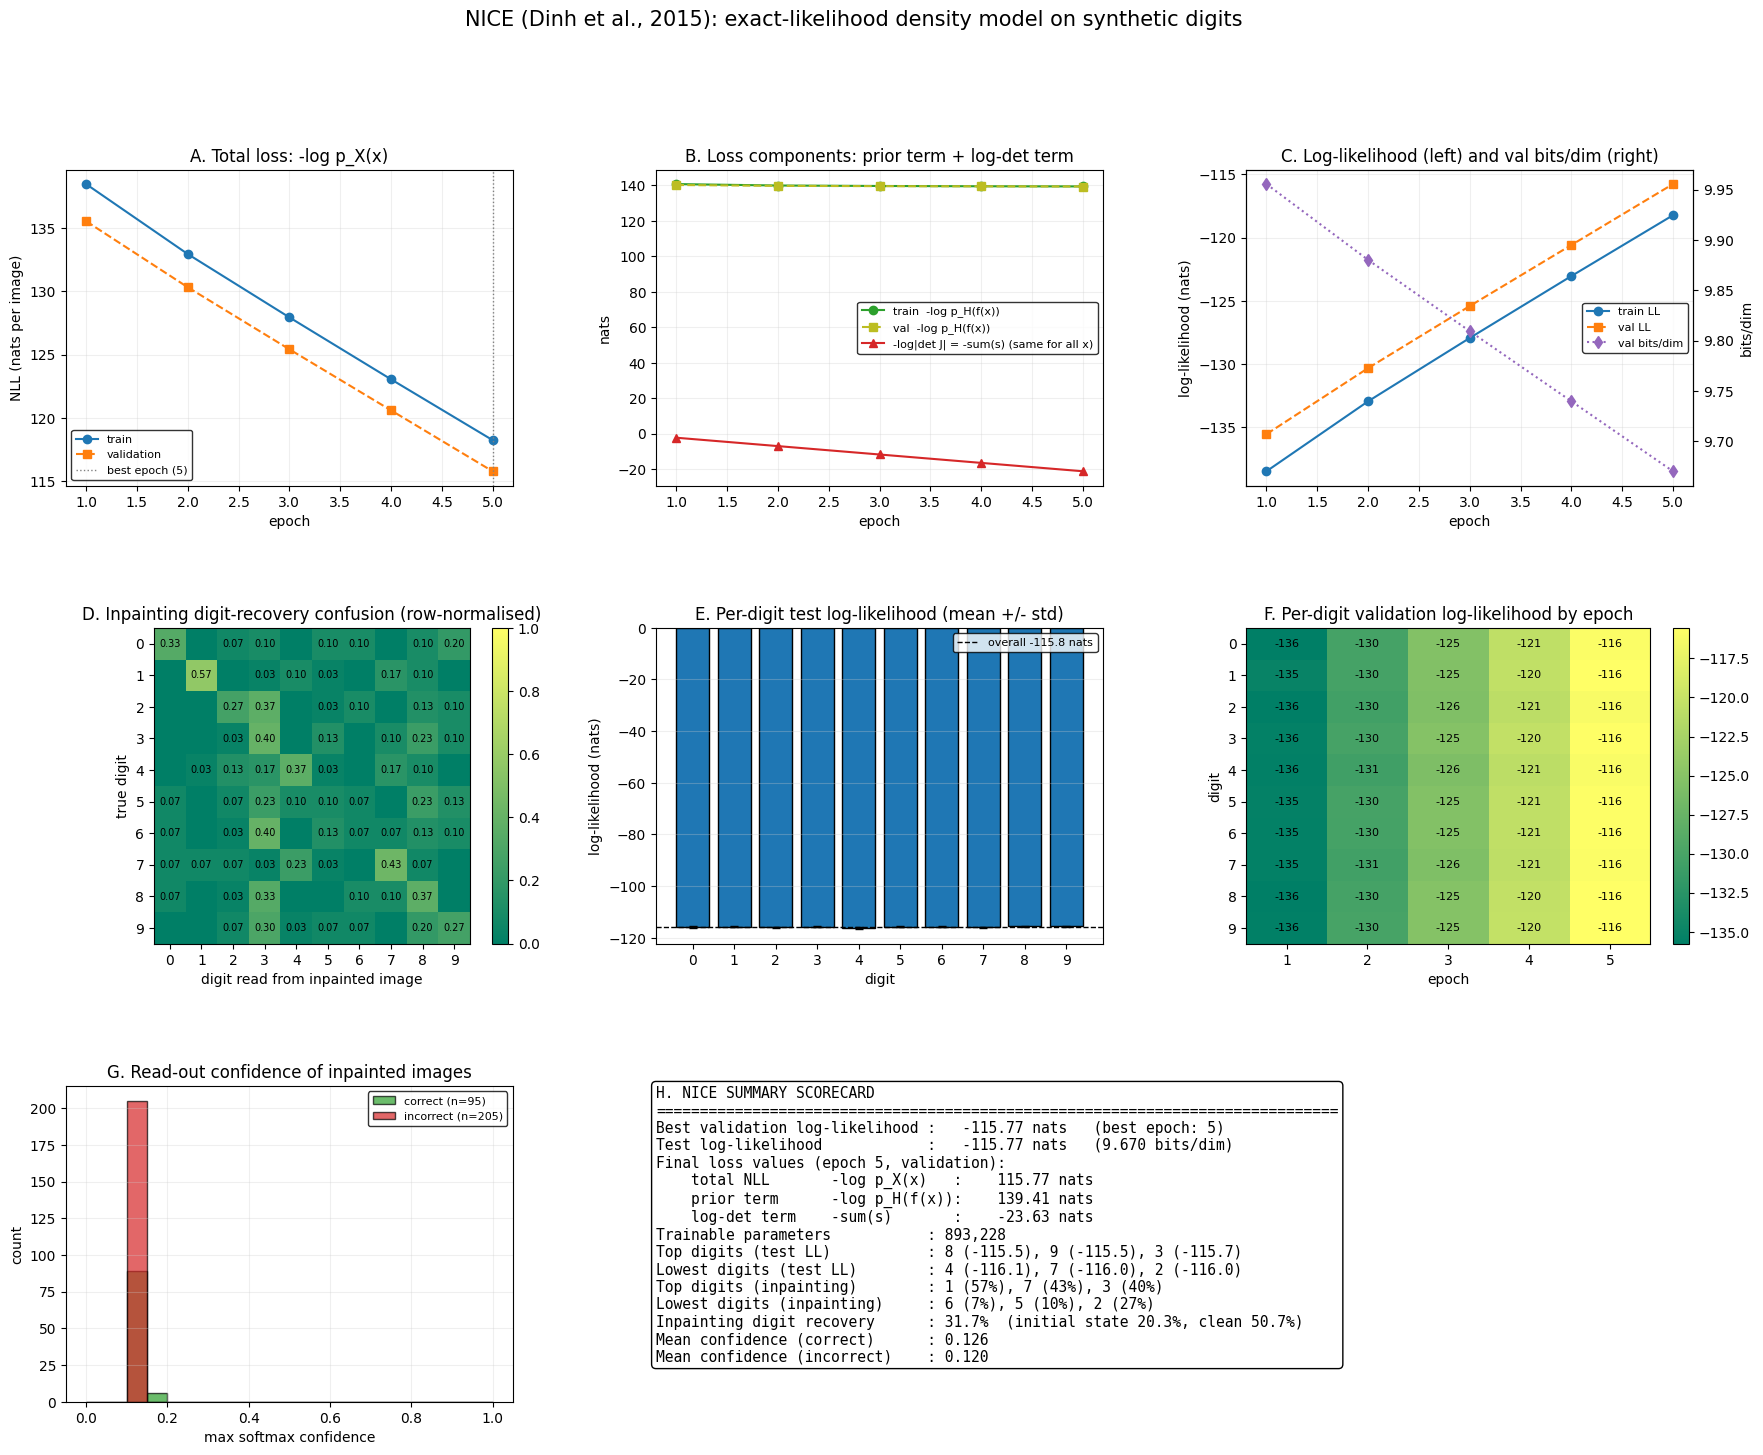

In [9]:

# =============================================================================
# 6. SUMMARY DASHBOARD (final visualisation)
# =============================================================================
# Adaptation of the generic dashboard template to a density-estimation paper:
#   A  total NLL (the single training objective)
#   B  its two components: prior term and log-determinant term
#   C  log-likelihood (paper's metric) and bits/dim
#   D  a classification confusion matrix does not exist for an unsupervised
#      density model. The closest paper-grounded analogue is digit-recovery
#      confusion after INPAINTING (Sec. 5.2): true digit vs. the digit read
#      from the model's completed image.
#   E  per-digit test log-likelihood ("class" = digit identity)
#   F  per-digit validation log-likelihood across epochs
#   G  read-out confidence of inpainted images, split by correct vs. incorrect
#   H  text scorecard
plt.style.use("default")
plt.rcParams.update(WHITE_THEME)

fig = plt.figure(figsize=(21, 16), facecolor="white")
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.32)

# ---- Panel A ----
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs, history["train_nll"], "o-", color="tab:blue", label="train")
axA.plot(epochs, history["val_nll"], "s--", color="tab:orange", label="validation")
axA.axvline(best_epoch, color="gray", ls=":", lw=1, label=f"best epoch ({best_epoch})")
axA.set(title="A. Total loss: -log p_X(x)", xlabel="epoch", ylabel="NLL (nats per image)")
axA.grid(alpha=.3); axA.legend(fontsize=8); style_ax(axA)

# ---- Panel B ----
axB = fig.add_subplot(gs[0, 1])
axB.plot(epochs, history["train_prior"], "o-", color="tab:green", label="train  -log p_H(f(x))")
axB.plot(epochs, history["val_prior"], "s--", color="tab:olive", label="val  -log p_H(f(x))")
axB.plot(epochs, history["train_logdet"], "^-", color="tab:red",
         label="-log|det J| = -sum(s) (same for all x)")
axB.set(title="B. Loss components: prior term + log-det term", xlabel="epoch", ylabel="nats")
axB.grid(alpha=.3); axB.legend(fontsize=8); style_ax(axB)

# ---- Panel C ----
axC = fig.add_subplot(gs[0, 2])
l1 = axC.plot(epochs, history["train_ll"], "o-", color="tab:blue", label="train LL")
l2 = axC.plot(epochs, history["val_ll"], "s--", color="tab:orange", label="val LL")
axC.set(title="C. Log-likelihood (left) and val bits/dim (right)", xlabel="epoch",
        ylabel="log-likelihood (nats)")
axC.grid(alpha=.3)
axC2 = axC.twinx()
l3 = axC2.plot(epochs, history["val_bpd"], "d:", color="tab:purple", label="val bits/dim")
axC2.set_ylabel("bits/dim")
lines = l1 + l2 + l3
axC.legend(lines, [l.get_label() for l in lines], fontsize=8, loc="center right")
style_ax(axC); style_ax(axC2)

# ---- Panel D ----
axD = fig.add_subplot(gs[1, 0])
imD = axD.imshow(cm_norm, cmap="summer", vmin=0, vmax=1)
for r in range(N_CLASSES):
    for c in range(N_CLASSES):
        if cm_norm[r, c] > 0:
            axD.text(c, r, f"{cm_norm[r, c]:.2f}", ha="center", va="center",
                     fontsize=7, color="black")
axD.set_xticks(range(N_CLASSES)); axD.set_yticks(range(N_CLASSES))
axD.set_xticklabels(DIGIT_NAMES); axD.set_yticklabels(DIGIT_NAMES)
axD.set(title="D. Inpainting digit-recovery confusion (row-normalised)",
        xlabel="digit read from inpainted image", ylabel="true digit")
cbD = fig.colorbar(imD, ax=axD, fraction=0.046)
cbD.ax.tick_params(colors="black")
style_ax(axD)

# ---- Panel E ----
axE = fig.add_subplot(gs[1, 1])
pc_ll = test_eval["per_class_ll"]
pc_std = np.array([test_eval["ll_all"][test_eval["labels"] == k].std() for k in range(N_CLASSES)])
axE.bar(range(N_CLASSES), pc_ll, yerr=pc_std, color="tab:blue", edgecolor="black",
        capsize=3, ecolor="black")
axE.axhline(test_eval["ll"], color="black", ls="--", lw=1,
            label=f"overall {test_eval['ll']:.1f} nats")
axE.set_xticks(range(N_CLASSES)); axE.set_xticklabels(DIGIT_NAMES)
axE.set(title="E. Per-digit test log-likelihood (mean +/- std)", xlabel="digit",
        ylabel="log-likelihood (nats)")
axE.grid(axis="y", alpha=.3); axE.legend(fontsize=8); style_ax(axE)

# ---- Panel F ----
axF = fig.add_subplot(gs[1, 2])
heat = np.stack(history["val_class_ll"], axis=1)          # (classes, epochs)
imF = axF.imshow(heat, cmap="summer", aspect="auto")
for r in range(N_CLASSES):
    for c in range(EPOCHS):
        axF.text(c, r, f"{heat[r, c]:.0f}", ha="center", va="center", fontsize=8, color="black")
axF.set_xticks(range(EPOCHS)); axF.set_xticklabels([str(e) for e in epochs])
axF.set_yticks(range(N_CLASSES)); axF.set_yticklabels(DIGIT_NAMES)
axF.set(title="F. Per-digit validation log-likelihood by epoch", xlabel="epoch", ylabel="digit")
cbF = fig.colorbar(imF, ax=axF, fraction=0.046)
cbF.ax.tick_params(colors="black")
style_ax(axF)

# ---- Panel G ----
axG = fig.add_subplot(gs[2, 0])
bins = np.linspace(0, 1, 21)
axG.hist(conf_inp[correct], bins=bins, alpha=0.7, color="tab:green", edgecolor="black",
         label=f"correct (n={int(correct.sum())})")
axG.hist(conf_inp[~correct], bins=bins, alpha=0.7, color="tab:red", edgecolor="black",
         label=f"incorrect (n={int((~correct).sum())})")
axG.set(title="G. Read-out confidence of inpainted images", xlabel="max softmax confidence",
        ylabel="count")
axG.grid(alpha=.3); axG.legend(fontsize=8); style_ax(axG)

# ---- Panel H ----
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")
order_ll = np.argsort(pc_ll)
order_inp = np.argsort(per_class_inp_acc)
mean_conf_ok = conf_inp[correct].mean() if correct.any() else float("nan")
mean_conf_bad = conf_inp[~correct].mean() if (~correct).any() else float("nan")
score_lines = [
    "H. NICE SUMMARY SCORECARD",
    "=" * 78,
    f"Best validation log-likelihood : {best_val_ll:9.2f} nats   (best epoch: {best_epoch})",
    f"Test log-likelihood            : {test_eval['ll']:9.2f} nats   ({test_eval['bpd']:.3f} bits/dim)",
    f"Final loss values (epoch {EPOCHS}, validation):",
    f"    total NLL       -log p_X(x)   : {history['val_nll'][-1]:9.2f} nats",
    f"    prior term      -log p_H(f(x)): {history['val_prior'][-1]:9.2f} nats",
    f"    log-det term    -sum(s)       : {history['val_logdet'][-1]:9.2f} nats",
    f"Trainable parameters           : {n_params:,}",
    f"Top digits (test LL)           : " + ", ".join(f"{k} ({pc_ll[k]:.1f})" for k in order_ll[::-1][:3]),
    f"Lowest digits (test LL)        : " + ", ".join(f"{k} ({pc_ll[k]:.1f})" for k in order_ll[:3]),
    f"Top digits (inpainting)        : " + ", ".join(f"{k} ({per_class_inp_acc[k]:.0%})" for k in order_inp[::-1][:3]),
    f"Lowest digits (inpainting)     : " + ", ".join(f"{k} ({per_class_inp_acc[k]:.0%})" for k in order_inp[:3]),
    f"Inpainting digit recovery      : {acc_inp:.1%}  (initial state {acc_init:.1%}, clean {acc_clean:.1%})",
    f"Mean confidence (correct)      : {mean_conf_ok:.3f}",
    f"Mean confidence (incorrect)    : {mean_conf_bad:.3f}",
]
axH.text(0.0, 1.0, "\n".join(score_lines), va="top", ha="left", family="monospace",
         fontsize=10.5, color="black", transform=axH.transAxes,
         bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"))

fig.suptitle("NICE (Dinh et al., 2015): exact-likelihood density model on synthetic digits",
             fontsize=15, color="black")

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight", facecolor="white")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

In [10]:
# =============================================================================
#  NICE: NON-LINEAR INDEPENDENT COMPONENTS ESTIMATION
#  (Dinh, Krueger & Bengio, ICLR 2015 workshop)
#  Educational PyTorch replication on a CIFAR-10 subset from Hugging Face.
# =============================================================================
#
#  STEP 0 - WHAT THE PAPER ACTUALLY DOES (analysis done before writing code)
#  -------------------------------------------------------------------------
#  1. TASK TYPE
#     Unsupervised density estimation / generative modelling of images
#     (Sec. 2, Sec. 5.1), evaluated by exact test log-likelihood. Two
#     downstream uses:
#       - unbiased ancestral sampling  h ~ p_H(h), x = f^{-1}(h)   (Eq. 2, Fig. 5d)
#       - inpainting by likelihood maximisation                     (Sec. 5.2)
#     NOT classification: CIFAR-10 labels are never used for training.
#
#  2. MODEL ARCHITECTURE
#     f = S o f4 o f3 o f2 o f1 o ZCA, where each f_k is an ADDITIVE COUPLING
#     LAYER (Sec. 3.2, Eq. 3 / Eq. 4):
#         y_I1 = x_I1,   y_I2 = x_I2 + m(x_I1)      inverse: x_I2 = y_I2 - m(y_I1)
#     - I1 / I2 = odd / even components, roles alternating (Sec. 5.1)
#     - m^(k) = deep ReLU MLP with linear outputs; paper uses 4 hidden layers
#       of 2000 units for CIFAR-10 (Fig. 3)
#     - final diagonal scaling h = exp(s) * h^(4)                 (Sec. 3.3)
#     - factorial LOGISTIC prior for CIFAR-10                      (Sec. 5.1)
#     - "exact ZCA on SVHN and CIFAR-10" preprocessing             (Sec. 5.1)
#
#  3. DATA / INPUT-OUTPUT STRUCTURE (CIFAR-10, Sec. 5.1)
#     32x32x3 colour images flattened to x in R^3072. For CIFAR-10 the paper
#     adds "uniform noise of 1/128 and rescale[s] the data to be in [-1,1]^D".
#     One example = one vector; the target is the example itself
#     (maximise log p_X(x)).
#
#  4. LOSS / TRAINING OBJECTIVE (one unified objective, Eq. 1 + Sec. 3.3)
#        -log p_X(x) = -sum_d log p_Hd(h_d)  -  sum_d s_d  -  log|det W_zca|
#                       \__ prior term __/    \_ learned _/   \_ constant  _/
#     Every component is logged separately.
#
#  5. EVALUATION METRIC
#     Exact log-likelihood in nats per image (Fig. 3/4: 5371.78 on CIFAR-10).
#     Bits/dim is shown as a standard re-expression of the same quantity.
#
#  6. "CLASSES" / PREDICTION UNITS
#     A density model has no output classes. The 10 CIFAR-10 categories are
#     used ONLY as analysis labels: per-class log-likelihood, and class
#     recovery after inpainting (read out with a k-NN probe in pixel space).
# =============================================================================

import io
import math
import random
import time
import copy
import sys
import subprocess

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, Image as IPImage

plt.style.use("default")            # normal matplotlib colours


def show_fig(fig):
    """Render a figure to an in-memory PNG buffer and display it inline."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    buf.seek(0)
    display(IPImage(data=buf.read()))
    plt.close(fig)

In [11]:

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HF_DATASET_ID = "uoft-cs/cifar10"   # official CIFAR-10 on the Hugging Face Hub
C, IMG = 3, 32
D = C * IMG * IMG                   # 3072, as in Fig. 3

# Subset sizes: class-balanced, large enough for stable per-class statistics
# (200 train / 40 val / 40 test images per class), small enough for a short
# 5-epoch educational run.
N_TRAIN_PER_CLASS, N_VAL_PER_CLASS, N_TEST_PER_CLASS = 200, 40, 40
# ZCA statistics need more samples than dimensions (3072) for a well-posed
# covariance, so we estimate them on 10,000 unlabeled training images
# (never on val/test). The paper computes ZCA on the full training set.
N_ZCA = 10000
ZCA_EPS = 1e-2                      # regulariser added to covariance eigenvalues

BATCH_SIZE = 64
EPOCHS = 5
N_COUPLING = 4                      # "a stack of four coupling layers" (Sec. 5.1)
HIDDEN = 512                        # paper (CIFAR-10): 2000 units -> scaled down
N_HIDDEN = 4                        # paper (CIFAR-10): 4 hidden layers (kept)
PRIOR = "logistic"                  # paper: logistic prior for CIFAR-10

# Optimiser (Sec. 5.1): "AdaM with learning rate 1e-3, momentum 0.9,
# beta2 = 0.01, lambda = 1, epsilon = 1e-4". In the early Adam notation
# beta2 = (1 - decay), so beta2 = 0.01 corresponds to PyTorch betas[1] = 0.99.
LR, BETAS, ADAM_EPS = 1e-3, (0.9, 0.99), 1e-4

INPAINT_PER_CLASS = 20              # 200 test images are inpainted
INPAINT_ITERS = 200
GRAD_CLAMP = 1.0                    # safeguard, see inpaint() docstring
KNN_K = 10                          # k-NN probe used to read out the class

print(f"Device: {device} | D = {D} | prior = {PRIOR}")

Device: cuda | D = 3072 | prior = logistic


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Fetching subsets ...

=== DATASET SANITY CHECK ===
Source                   : Hugging Face 'uoft-cs/cifar10'
Train / Val / Test sizes : 2000 / 400 / 400  (+ 10000 unlabeled images for ZCA statistics)
One batch x shape        : (64, 3072)  (batch, 3*32*32)
x value range            : [-1.0000, 1.0000]  (dequantized, in [-1,1])
Training target          : the input itself (maximise log p_X(x)); labels unused
Analysis label range     : 0..9
'Class' vocabulary       : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train images per class   : [200, 200, 200, 200, 200, 200, 200, 200, 200, 200]


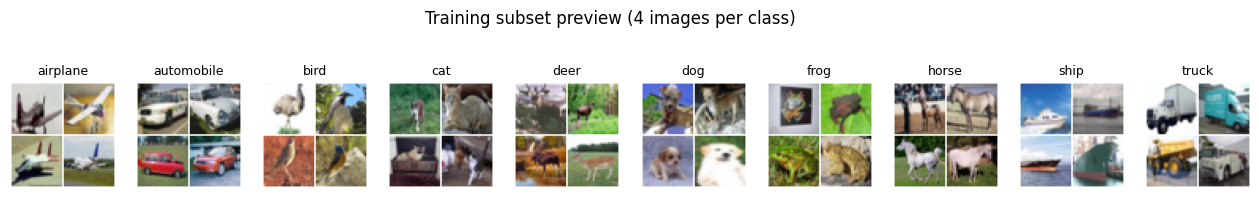

In [12]:
# =============================================================================
# 1. DATA: CIFAR-10 FROM HUGGING FACE (class-balanced subset)
# =============================================================================
try:
    from datasets import load_dataset
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
    from datasets import load_dataset

try:
    hf = load_dataset(HF_DATASET_ID)
except Exception as e:
    print(f"Could not load '{HF_DATASET_ID}' ({e}); trying 'cifar10'.")
    hf = load_dataset("cifar10")

img_col = "img" if "img" in hf["train"].column_names else "image"
CLASS_NAMES = hf["train"].features["label"].names
N_CLASSES = len(CLASS_NAMES)

sel_rng = np.random.default_rng(SEED)
train_all_labels = np.asarray(hf["train"]["label"])
test_all_labels = np.asarray(hf["test"]["label"])

train_idx, val_idx, test_idx = [], [], []
for k in range(N_CLASSES):
    idx_k = sel_rng.permutation(np.where(train_all_labels == k)[0])
    train_idx += idx_k[:N_TRAIN_PER_CLASS].tolist()
    val_idx += idx_k[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS].tolist()
    tidx_k = sel_rng.permutation(np.where(test_all_labels == k)[0])
    test_idx += tidx_k[:N_TEST_PER_CLASS].tolist()
train_idx = sel_rng.permutation(train_idx).tolist()

# ZCA pool = training subset + extra unlabeled training images (no val images)
pool = np.setdiff1d(np.arange(len(train_all_labels)), np.array(val_idx + train_idx))
extra = sel_rng.choice(pool, N_ZCA - len(train_idx), replace=False)
zca_idx = train_idx + extra.tolist()


def fetch(split, idx):
    """Return (pixels uint8 (N, 3072) in CHW order, labels int64 (N,))."""
    sub = hf[split].select([int(i) for i in idx])
    imgs = np.stack([np.asarray(im.convert("RGB"), dtype=np.uint8) for im in sub[img_col]])
    pix = imgs.transpose(0, 3, 1, 2).reshape(len(idx), -1)   # HWC -> CHW -> flat
    return pix, np.asarray(sub["label"], dtype=np.int64)


print("Fetching subsets ...")
train_pix, train_lab = fetch("train", train_idx)
val_pix, val_lab = fetch("train", val_idx)
test_pix, test_lab = fetch("test", test_idx)
zca_pix, _ = fetch("train", zca_idx)


class DequantizedCIFAR(Dataset):
    """
    Returns (x, label) with x in [-1, 1]^3072.
    Sec. 5.1 (CIFAR-10): "We add a uniform noise of 1/128 and rescale the data
    to be in [-1,1]^D", i.e. x = (pixel + u) / 128 - 1 with u ~ U(0,1).
      - training split: fresh noise at every access (as in the paper)
      - val/test splits: noise drawn once and fixed, so log-likelihoods are
        comparable across epochs
    """

    def __init__(self, pixels, labels, fixed_noise_seed=None):
        self.pixels = torch.from_numpy(pixels).float()
        self.labels = torch.from_numpy(labels)
        self.fixed_noise = None
        if fixed_noise_seed is not None:
            g = torch.Generator().manual_seed(fixed_noise_seed)
            self.fixed_noise = torch.rand(self.pixels.shape, generator=g)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        u = self.fixed_noise[i] if self.fixed_noise is not None else torch.rand(D)
        return (self.pixels[i] + u) / 128.0 - 1.0, self.labels[i]


train_ds = DequantizedCIFAR(train_pix, train_lab)
val_ds = DequantizedCIFAR(val_pix, val_lab, fixed_noise_seed=1)
test_ds = DequantizedCIFAR(test_pix, test_lab, fixed_noise_seed=2)

g_loader = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g_loader)
val_loader = DataLoader(val_ds, batch_size=200, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=200, shuffle=False)


def to_hwc(v):
    """Flattened CHW vectors in [-1,1] -> HWC images in [0,1] for imshow."""
    v = np.asarray(v).reshape(-1, C, IMG, IMG).transpose(0, 2, 3, 1)
    return np.clip((v + 1.0) / 2.0, 0.0, 1.0)


def tile_rgb(imgs, nrow, ncol, pad=1):
    """Arrange flattened colour images into a single grid image."""
    imgs = to_hwc(imgs)
    canvas = np.ones((nrow * (IMG + pad) + pad, ncol * (IMG + pad) + pad, 3))
    for k in range(min(len(imgs), nrow * ncol)):
        r, c = divmod(k, ncol)
        r0, c0 = pad + r * (IMG + pad), pad + c * (IMG + pad)
        canvas[r0:r0 + IMG, c0:c0 + IMG] = imgs[k]
    return canvas


# ---------------------------- sanity check ----------------------------------
xb, yb = next(iter(train_loader))
print("\n=== DATASET SANITY CHECK ===")
print(f"Source                   : Hugging Face '{HF_DATASET_ID}'")
print(f"Train / Val / Test sizes : {len(train_ds)} / {len(val_ds)} / {len(test_ds)}  "
      f"(+ {N_ZCA} unlabeled images for ZCA statistics)")
print(f"One batch x shape        : {tuple(xb.shape)}  (batch, 3*32*32)")
print(f"x value range            : [{xb.min():.4f}, {xb.max():.4f}]  (dequantized, in [-1,1])")
print(f"Training target          : the input itself (maximise log p_X(x)); labels unused")
print(f"Analysis label range     : {int(yb.min())}..{int(yb.max())}")
print(f"'Class' vocabulary       : {CLASS_NAMES}")
print(f"Train images per class   : {np.bincount(train_lab, minlength=N_CLASSES).tolist()}")

fig, axes = plt.subplots(1, N_CLASSES, figsize=(16, 2.6))
for k, ax in enumerate(axes):
    ids = np.where(train_lab == k)[0][:4]
    ax.imshow(tile_rgb(np.stack([train_ds[int(i)][0].numpy() for i in ids]), 2, 2))
    ax.set_title(CLASS_NAMES[k], fontsize=9)
    ax.axis("off")
fig.suptitle("Training subset preview (4 images per class)")
show_fig(fig)


In [13]:

# =============================================================================
# 2. MODEL: ZCA + NICE, built from first principles
# =============================================================================


class ZCAWhitening(nn.Module):
    """
    Fixed (non-trainable) ZCA whitening, "exact ZCA on SVHN and CIFAR-10"
    (Sec. 5.1):  z = W (x - mu),  W = U diag(1/sqrt(lambda + eps)) U^T.
    Because it is an invertible linear map, the change-of-variables formula
    (Eq. 1) adds the constant log|det W| = -0.5 * sum log(lambda + eps), so
    the reported likelihood is a density over pixel space x, not over z.
    """

    def __init__(self, data, eps):
        super().__init__()
        X = data.double()
        mu = X.mean(0)
        Xc = X - mu
        cov = Xc.T @ Xc / (X.shape[0] - 1)
        evals, evecs = torch.linalg.eigh(cov)
        evals = evals.clamp(min=0.0) + eps
        W = (evecs * evals.rsqrt()) @ evecs.T
        W_inv = (evecs * evals.sqrt()) @ evecs.T
        self.register_buffer("mu", mu.float())
        self.register_buffer("W", W.float())
        self.register_buffer("W_inv", W_inv.float())
        self.register_buffer("log_det", (-0.5 * torch.log(evals).sum()).float())

    def forward(self, x):
        return (x - self.mu) @ self.W.T

    def inverse(self, z):
        return z @ self.W_inv.T + self.mu


class CouplingMLP(nn.Module):
    """
    Coupling function m (Sec. 3.2, Sec. 5.1): a deep rectified network with
    linear output units. Any function works; it never has to be inverted.
    """

    def __init__(self, in_dim, out_dim, hidden, n_hidden):
        super().__init__()
        layers, d = [], in_dim
        for _ in range(n_hidden):
            layers += [nn.Linear(d, hidden), nn.ReLU()]
            d = hidden
        self.out = nn.Linear(d, out_dim)
        self.net = nn.Sequential(*layers, self.out)
        # Practical choice (not stated in the paper): zero-initialise the output
        # layer so every coupling layer starts as the identity map.
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, x):
        return self.net(x)


class AdditiveCouplingLayer(nn.Module):
    """
    Additive coupling layer (Sec. 3.2, Eq. 3 / Eq. 4):
        forward : y_I1 = x_I1,  y_I2 = x_I2 + m(x_I1)
        inverse : x_I1 = y_I1,  x_I2 = y_I2 - m(y_I1)
    Unit Jacobian determinant (volume preserving).
    Partition (Sec. 5.1): odd (I1) vs even (I2) components of the flattened
    vector; paper's 1-based "odd" = 0-based indices 0, 2, 4, ...
    """

    def __init__(self, dim, modify_even, hidden, n_hidden):
        super().__init__()
        idx = torch.arange(dim)
        odd, even = idx[0::2], idx[1::2]
        mod, cond = (even, odd) if modify_even else (odd, even)
        self.register_buffer("mod_idx", mod)
        self.register_buffer("cond_idx", cond)
        self.m = CouplingMLP(len(cond), len(mod), hidden, n_hidden)

    def forward(self, x):                                   # Eq. 3
        y = x.clone()
        y[:, self.mod_idx] = x[:, self.mod_idx] + self.m(x[:, self.cond_idx])
        return y

    def inverse(self, y):                                   # Eq. 4
        x = y.clone()
        x[:, self.mod_idx] = y[:, self.mod_idx] - self.m(y[:, self.cond_idx])
        return x


class NICE(nn.Module):
    """
    Full model (Sec. 5.1 equations, preceded by ZCA):
        z     = ZCA(x)
        h1_I1 = z_I1           h1_I2 = z_I2  + m1(z_I1)
        h2_I2 = h1_I2          h2_I1 = h1_I1 + m2(h1_I2)
        h3_I1 = h2_I1          h3_I2 = h2_I2 + m3(h2_I1)
        h4_I2 = h3_I2          h4_I1 = h3_I1 + m4(h3_I2)
        h     = exp(s) * h4                                  (Sec. 3.3)
    (The paper's text writes m2(x_I2), m4(x_I2); for invertibility the argument
    must be the current value of the unchanged half, which we implement.)
        log p_X(x) = sum_d log p_Hd(h_d) + sum_d s_d + log|det W_zca|
    """

    def __init__(self, dim, n_coupling, hidden, n_hidden, prior, zca):
        super().__init__()
        self.dim, self.prior, self.zca = dim, prior, zca
        self.layers = nn.ModuleList([
            AdditiveCouplingLayer(dim, modify_even=(k % 2 == 0),
                                  hidden=hidden, n_hidden=n_hidden)
            for k in range(n_coupling)])
        self.s = nn.Parameter(torch.zeros(dim))   # S_dd = exp(s_d), Sec. 5.1

    def log_prior(self, h):                       # Sec. 3.4
        if self.prior == "logistic":
            return -(F.softplus(h) + F.softplus(-h)).sum(dim=1)
        return (-0.5 * (h ** 2 + math.log(2 * math.pi))).sum(dim=1)

    def forward(self, x):                         # encoder f (Fig. 1a)
        h = self.zca(x)
        for layer in self.layers:
            h = layer(h)
        h = h * torch.exp(self.s)
        n = x.shape[0]
        log_prior = self.log_prior(h)
        log_det_s = self.s.sum().expand(n)        # learned volume change
        log_det_zca = self.zca.log_det.expand(n)  # fixed preprocessing constant
        return h, log_prior, log_det_s, log_det_zca

    def log_likelihood(self, x):
        _, lp, lds, ldz = self.forward(x)
        return lp + lds + ldz

    def inverse(self, h):                         # decoder f^{-1} (Fig. 1b)
        x = h * torch.exp(-self.s)
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return self.zca.inverse(x)

    def sample_prior(self, n):
        if self.prior == "logistic":              # inverse-CDF sampling
            u = torch.rand(n, self.dim, device=self.s.device).clamp(1e-6, 1 - 1e-6)
            return torch.log(u) - torch.log1p(-u)
        return torch.randn(n, self.dim, device=self.s.device)

    @torch.no_grad()
    def sample(self, n):                          # Eq. 2
        return self.inverse(self.sample_prior(n))


print("Computing ZCA statistics ...")
g_zca = torch.Generator().manual_seed(SEED + 5)
zca_data = (torch.from_numpy(zca_pix).float()
            + torch.rand(zca_pix.shape, generator=g_zca)) / 128.0 - 1.0
zca = ZCAWhitening(zca_data, ZCA_EPS)
del zca_data, zca_pix
print(f"ZCA log|det W| = {zca.log_det.item():.2f} nats (constant term of the likelihood)")

model = NICE(D, N_COUPLING, HIDDEN, N_HIDDEN, PRIOR, zca).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"NICE model: ZCA + {N_COUPLING} additive coupling layers "
      f"(m = ReLU MLP {N_HIDDEN} x {HIDDEN}) | trainable parameters = {n_params:,}")

# Invertibility check: f^{-1}(f(x)) should reproduce x (output layers are
# randomised in a copy so the check is not trivially the identity map).
with torch.no_grad():
    test_model = copy.deepcopy(model)
    for layer in test_model.layers:
        nn.init.normal_(layer.m.out.weight, std=0.01)
    xs = xb[:8].to(device)
    rec = test_model.inverse(test_model(xs)[0])
    print(f"Invertibility check |f^-1(f(x)) - x|_max = {(rec - xs).abs().max().item():.2e}")
    del test_model



Computing ZCA statistics ...
ZCA log|det W| = 5945.87 nats (constant term of the likelihood)
NICE model: ZCA + 4 additive coupling layers (m = ReLU MLP 4 x 512) | trainable parameters = 9,454,592
Invertibility check |f^-1(f(x)) - x|_max = 1.13e-06


In [14]:
# =============================================================================
# 3. TRAINING (exact maximum likelihood, Sec. 5.1)
# =============================================================================


def bits_per_dim(ll_nats):
    """
    Bits per dimension of the discrete 256-level data. In [-1,1] space each
    pixel bin has width 2/256 = 1/128, so log P(discrete) ~= log p(x) - D log 128.
    """
    return (-ll_nats + D * math.log(128)) / (D * math.log(2))


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    lls, lps, ldss, labs = [], [], [], []
    for x, y in loader:
        x = x.to(device)
        _, lp, lds, ldz = model(x)
        lls.append((lp + lds + ldz).cpu()); lps.append(lp.cpu())
        ldss.append(lds.cpu()); labs.append(y)
    ll = torch.cat(lls).numpy(); lp = torch.cat(lps).numpy()
    lds = torch.cat(ldss).numpy(); lab = torch.cat(labs).numpy()
    per_class = np.array([ll[lab == k].mean() for k in range(N_CLASSES)])
    return {"ll": float(ll.mean()), "nll": float(-ll.mean()),
            "prior": float(-lp.mean()), "logdet_s": float(-lds.mean()),
            "logdet_zca": float(-model.zca.log_det.item()),
            "bpd": bits_per_dim(float(ll.mean())),
            "per_class_ll": per_class, "ll_all": ll, "labels": lab}


optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=BETAS, eps=ADAM_EPS)

history = {k: [] for k in ["train_nll", "val_nll", "train_prior", "val_prior",
                           "train_logdet_s", "val_logdet_s", "logdet_zca",
                           "train_ll", "val_ll", "train_bpd", "val_bpd", "val_class_ll"]}
best_val_ll, best_epoch, best_state = -float("inf"), 0, None

print("\n=== TRAINING (5 epochs, objective = exact negative log-likelihood) ===")
for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    n_seen, s_nll, s_prior, s_lds, s_ll = 0, 0.0, 0.0, 0.0, 0.0
    for x, _ in train_loader:                  # labels ignored: unsupervised
        x = x.to(device)
        h, lp, lds, ldz = model(x)
        ll = lp + lds + ldz                    # log p_X(x)
        loss = -ll.mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x.shape[0]
        n_seen += bs
        s_nll += loss.item() * bs
        s_prior += (-lp).sum().item()          # component 1: -log p_H(f(x))
        s_lds += (-lds).sum().item()           # component 2: -sum(s)
        s_ll += ll.sum().item()

    # Train metrics = running averages over the epoch; val = end-of-epoch weights.
    tr_ll = s_ll / n_seen
    history["train_nll"].append(s_nll / n_seen)
    history["train_prior"].append(s_prior / n_seen)
    history["train_logdet_s"].append(s_lds / n_seen)
    history["train_ll"].append(tr_ll)
    history["train_bpd"].append(bits_per_dim(tr_ll))

    val = evaluate(model, val_loader)
    history["val_nll"].append(val["nll"]); history["val_prior"].append(val["prior"])
    history["val_logdet_s"].append(val["logdet_s"]); history["logdet_zca"].append(val["logdet_zca"])
    history["val_ll"].append(val["ll"]); history["val_bpd"].append(val["bpd"])
    history["val_class_ll"].append(val["per_class_ll"])

    # Model selection by validation log-likelihood (Sec. 5.1)
    if val["ll"] > best_val_ll:
        best_val_ll, best_epoch = val["ll"], epoch
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch}/{EPOCHS} | train NLL {history['train_nll'][-1]:10.2f} "
          f"(prior {history['train_prior'][-1]:9.2f}, -sum(s) {history['train_logdet_s'][-1]:9.2f}, "
          f"ZCA {val['logdet_zca']:9.2f}) | val LL {val['ll']:9.2f} nats, "
          f"{val['bpd']:.3f} bits/dim | {time.time() - t0:.1f}s")

model.load_state_dict(best_state)
print(f"\nLoaded best model from epoch {best_epoch} (val log-likelihood {best_val_ll:.2f} nats)")



=== TRAINING (5 epochs, objective = exact negative log-likelihood) ===
Epoch 1/5 | train NLL   -1505.69 (prior   4486.66, -sum(s)    -46.48, ZCA  -5945.87) | val LL   1526.88 nats, 6.283 bits/dim | 0.4s
Epoch 2/5 | train NLL   -1589.71 (prior   4500.71, -sum(s)   -144.55, ZCA  -5945.87) | val LL   1608.84 nats, 6.244 bits/dim | 0.4s
Epoch 3/5 | train NLL   -1672.57 (prior   4515.58, -sum(s)   -242.28, ZCA  -5945.87) | val LL   1689.65 nats, 6.206 bits/dim | 0.4s
Epoch 4/5 | train NLL   -1754.68 (prior   4530.64, -sum(s)   -339.45, ZCA  -5945.87) | val LL   1769.12 nats, 6.169 bits/dim | 0.5s
Epoch 5/5 | train NLL   -1835.91 (prior   4546.32, -sum(s)   -436.36, ZCA  -5945.87) | val LL   1847.39 nats, 6.132 bits/dim | 0.4s

Loaded best model from epoch 5 (val log-likelihood 1847.39 nats)


In [15]:

# =============================================================================
# 4. EVALUATION + PREDICTION PIPELINES
# =============================================================================

# ---- 4a. Exact test log-likelihood (Fig. 3/4) ----
test_eval = evaluate(model, test_loader)
print("\n=== TEST LOG-LIKELIHOOD (exact, as in Fig. 3) ===")
print(f"Test log-likelihood : {test_eval['ll']:.2f} nats per image "
      f"({test_eval['bpd']:.3f} bits/dim)   [paper, full model: 5371.78 nats]")
for k in range(N_CLASSES):
    print(f"  {CLASS_NAMES[k]:<11}: mean log-likelihood {test_eval['per_class_ll'][k]:10.2f} nats")

# ---- 4b. Unbiased ancestral sampling (Eq. 2, Fig. 5d) ----
model.eval()
torch.manual_seed(SEED)
samples = model.sample(64).clamp(-1, 1).cpu().numpy()

# ---- 4c. Inpainting (Sec. 5.2) ----
MASK_TYPES = ["top rows", "bottom rows", "odd pixels", "even pixels", "left side",
              "right side", "middle vertically", "middle horizontally",
              "75% random", "90% random"]            # the ten masks of Fig. 6


def make_mask(kind, rng):
    """Spatial mask (same for all 3 channels); True = hidden pixel."""
    grid = np.zeros((IMG, IMG), dtype=bool)
    half = IMG // 2
    if kind == "top rows":              grid[:half, :] = True
    elif kind == "bottom rows":         grid[half:, :] = True
    elif kind == "odd pixels":          grid.reshape(-1)[0::2] = True
    elif kind == "even pixels":         grid.reshape(-1)[1::2] = True
    elif kind == "left side":           grid[:, :half] = True
    elif kind == "right side":          grid[:, half:] = True
    elif kind == "middle vertically":   grid[:, 10:22] = True
    elif kind == "middle horizontally": grid[10:22, :] = True
    elif kind == "75% random":          grid = rng.random((IMG, IMG)) < 0.75
    elif kind == "90% random":          grid = rng.random((IMG, IMG)) < 0.90
    return np.tile(grid.reshape(1, -1), (C, 1)).reshape(-1)   # CHW flatten


def inpaint(model, x_true, mask, n_iter):
    """
    Sec. 5.2: clamp observed pixels x_O and maximise log p_X((x_O, x_H)) over
    the hidden pixels by projected stochastic gradient ascent:
        x_H <- x_H + alpha_i * (d log p_X / d x_H + eps),  eps ~ N(0, I),
        alpha_i = 10 / (100 + i),  then projection onto [-1, 1].
    Hidden pixels start from uniform noise (Fig. 6b "initial state").
    Deviation: ZCA whitening amplifies low-variance directions, which makes the
    raw likelihood gradient very large on CIFAR-10. We therefore clamp the
    gradient element-wise to [-GRAD_CLAMP, GRAD_CLAMP] for stability (the
    paper demonstrated inpainting only on MNIST, without ZCA).
    """
    model.eval()
    x = x_true.clone()
    x[mask] = (torch.rand_like(x) * 2 - 1)[mask]
    init_state = x.clone()
    for i in range(n_iter):
        x = x.detach().requires_grad_(True)
        ll = model.log_likelihood(x).sum()
        grad, = torch.autograd.grad(ll, x)
        grad = grad.clamp(-GRAD_CLAMP, GRAD_CLAMP)
        alpha = 10.0 / (100.0 + i)
        x = x.detach() + alpha * (grad + torch.randn_like(x)) * mask.float()
        x = x.clamp(-1.0, 1.0)                         # projection
        x = torch.where(mask, x, x_true)               # observed pixels clamped
    return init_state, x.detach()


# Class read-out probe: NICE has no classifier, so we read the class of an
# image with a k-NN vote against the (mid-bin, non-noisy) training subset.
# Confidence = fraction of the K neighbours voting for the predicted class.
# This is a weak probe on CIFAR-10; its accuracy on CLEAN test images is
# reported as the reference ceiling.
train_ref = (torch.from_numpy(train_pix).float() + 0.5) / 128.0 - 1.0
train_lab_t = torch.from_numpy(train_lab)


def read_class(x):
    d = torch.cdist(x, train_ref)
    nn_idx = d.topk(KNN_K, largest=False).indices
    counts = F.one_hot(train_lab_t[nn_idx], N_CLASSES).sum(1).float()
    conf, pred = counts.max(1)
    return pred.numpy(), (conf / KNN_K).numpy()


inp_sel = np.concatenate([np.where(test_lab == k)[0][:INPAINT_PER_CLASS]
                          for k in range(N_CLASSES)])
x_inp_true = torch.stack([test_ds[int(i)][0] for i in inp_sel])
y_inp = test_lab[inp_sel]
mask_kind_idx = np.arange(len(inp_sel)) % len(MASK_TYPES)    # each class sees every mask
mask_rng = np.random.default_rng(SEED + 7)
masks = torch.from_numpy(np.stack([make_mask(MASK_TYPES[j], mask_rng) for j in mask_kind_idx]))

print(f"\nInpainting {len(inp_sel)} test images ({INPAINT_ITERS} iterations) ...")
torch.manual_seed(SEED + 11)
init_states, inpainted = inpaint(model, x_inp_true.to(device), masks.to(device), INPAINT_ITERS)
init_states, inpainted = init_states.cpu(), inpainted.cpu()

pred_clean, _ = read_class(x_inp_true)
pred_init, _ = read_class(init_states)
pred_inp, conf_inp = read_class(inpainted)
correct = pred_inp == y_inp
acc_clean = float((pred_clean == y_inp).mean())
acc_init = float((pred_init == y_inp).mean())
acc_inp = float(correct.mean())

mf = masks.float()
hidden_mse = (((inpainted - x_inp_true) ** 2) * mf).sum(1) / mf.sum(1).clamp(min=1)
init_mse = (((init_states - x_inp_true) ** 2) * mf).sum(1) / mf.sum(1).clamp(min=1)
with torch.no_grad():
    ll_true = model.log_likelihood(x_inp_true.to(device)).cpu().numpy()
    ll_inp = model.log_likelihood(inpainted.to(device)).cpu().numpy()

per_mask_acc = np.array([correct[mask_kind_idx == j].mean() for j in range(len(MASK_TYPES))])
per_mask_mse = np.array([hidden_mse[torch.from_numpy(mask_kind_idx == j)].mean().item()
                         for j in range(len(MASK_TYPES))])

cm = np.zeros((N_CLASSES, N_CLASSES))
for t, p in zip(y_inp, pred_inp):
    cm[t, p] += 1
cm_norm = cm / np.clip(cm.sum(1, keepdims=True), 1, None)
per_class_inp_acc = np.diag(cm_norm)

print("\n=== INPAINTING (Sec. 5.2) ===")
print(f"k-NN class read-out | clean test images   : {acc_clean:.1%} (probe ceiling)")
print(f"                    | initial noisy state : {acc_init:.1%}")
print(f"                    | after inpainting    : {acc_inp:.1%}")
print(f"Hidden-pixel MSE: initial state {init_mse.mean():.4f} -> inpainted {hidden_mse.mean():.4f}")

print("\n=== QUALITATIVE PREDICTIONS (one per mask type) ===")
print(f"{'idx':>4} | {'mask type':<19} | {'true class':<10} | {'recovered':<10} | conf | "
      f"hidden MSE | log p(true) | log p(inpainted)")
for j in range(len(MASK_TYPES)):
    i = int(np.where(mask_kind_idx == j)[0][0])
    print(f"{i:>4} | {MASK_TYPES[j]:<19} | {CLASS_NAMES[y_inp[i]]:<10} | "
          f"{CLASS_NAMES[pred_inp[i]]:<10} | {conf_inp[i]:.2f} | {hidden_mse[i].item():10.4f} | "
          f"{ll_true[i]:11.1f} | {ll_inp[i]:11.1f}")



=== TEST LOG-LIKELIHOOD (exact, as in Fig. 3) ===
Test log-likelihood : 1842.19 nats per image (6.135 bits/dim)   [paper, full model: 5371.78 nats]
  airplane   : mean log-likelihood    1886.49 nats
  automobile : mean log-likelihood    1750.18 nats
  bird       : mean log-likelihood    1870.92 nats
  cat        : mean log-likelihood    1867.39 nats
  deer       : mean log-likelihood    1923.96 nats
  dog        : mean log-likelihood    1862.10 nats
  frog       : mean log-likelihood    1796.59 nats
  horse      : mean log-likelihood    1776.31 nats
  ship       : mean log-likelihood    1898.74 nats
  truck      : mean log-likelihood    1789.18 nats

Inpainting 200 test images (200 iterations) ...

=== INPAINTING (Sec. 5.2) ===
k-NN class read-out | clean test images   : 28.0% (probe ceiling)
                    | initial noisy state : 19.0%
                    | after inpainting    : 23.5%
Hidden-pixel MSE: initial state 0.5940 -> inpainted 0.1310

=== QUALITATIVE PREDICTIONS (one pe

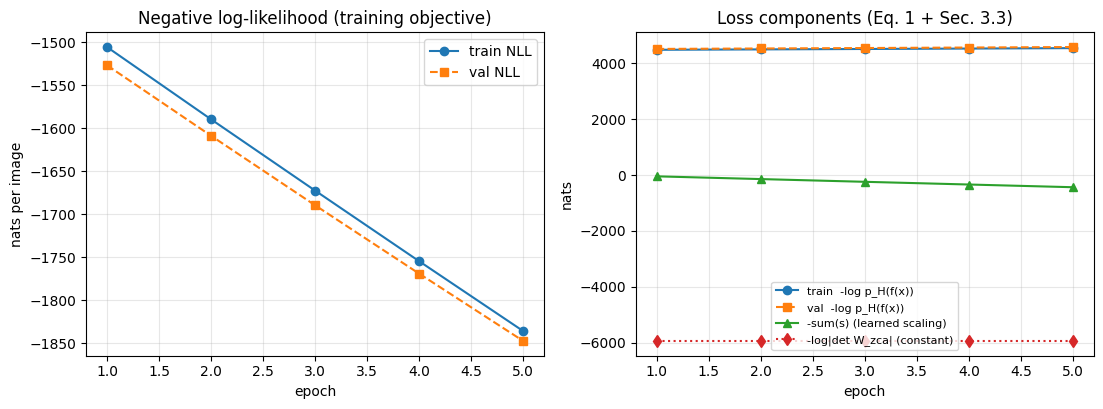

In [22]:

# =============================================================================
# 5. STANDARD EDUCATIONAL PLOTS
# =============================================================================
epochs = np.arange(1, EPOCHS + 1)

# ---- 5a. Loss curves and loss components ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(epochs, history["train_nll"], "o-", label="train NLL")
axes[0].plot(epochs, history["val_nll"], "s--", label="val NLL")
axes[0].set(title="Negative log-likelihood (training objective)", xlabel="epoch",
            ylabel="nats per image")
axes[0].grid(alpha=.3); axes[0].legend()
axes[1].plot(epochs, history["train_prior"], "o-", label="train  -log p_H(f(x))")
axes[1].plot(epochs, history["val_prior"], "s--", label="val  -log p_H(f(x))")
axes[1].plot(epochs, history["train_logdet_s"], "^-", label="-sum(s) (learned scaling)")
axes[1].plot(epochs, history["logdet_zca"], "d:", label="-log|det W_zca| (constant)")
axes[1].set(title="Loss components (Eq. 1 + Sec. 3.3)", xlabel="epoch", ylabel="nats")
axes[1].grid(alpha=.3); axes[1].legend(fontsize=8)
show_fig(fig)


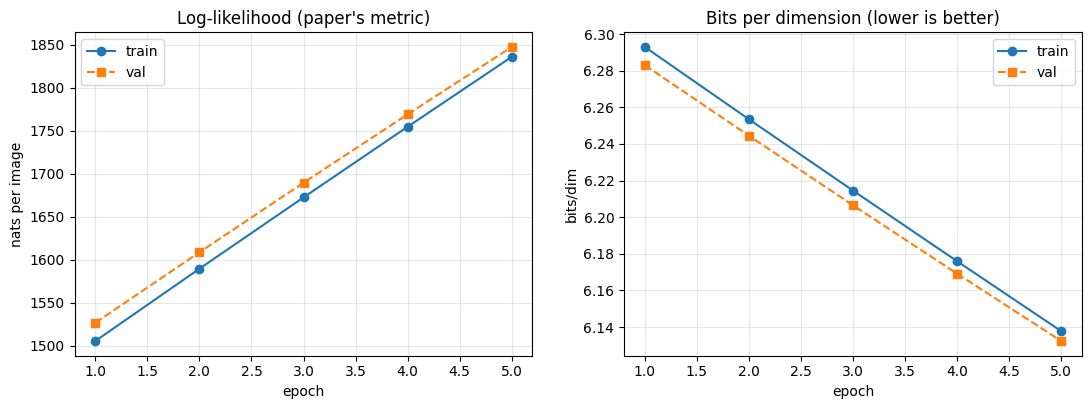

In [23]:

# ---- 5b. Log-likelihood and bits/dim ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(epochs, history["train_ll"], "o-", label="train")
axes[0].plot(epochs, history["val_ll"], "s--", label="val")
axes[0].set(title="Log-likelihood (paper's metric)", xlabel="epoch", ylabel="nats per image")
axes[0].grid(alpha=.3); axes[0].legend()
axes[1].plot(epochs, history["train_bpd"], "o-", label="train")
axes[1].plot(epochs, history["val_bpd"], "s--", label="val")
axes[1].set(title="Bits per dimension (lower is better)", xlabel="epoch", ylabel="bits/dim")
axes[1].grid(alpha=.3); axes[1].legend()
show_fig(fig)

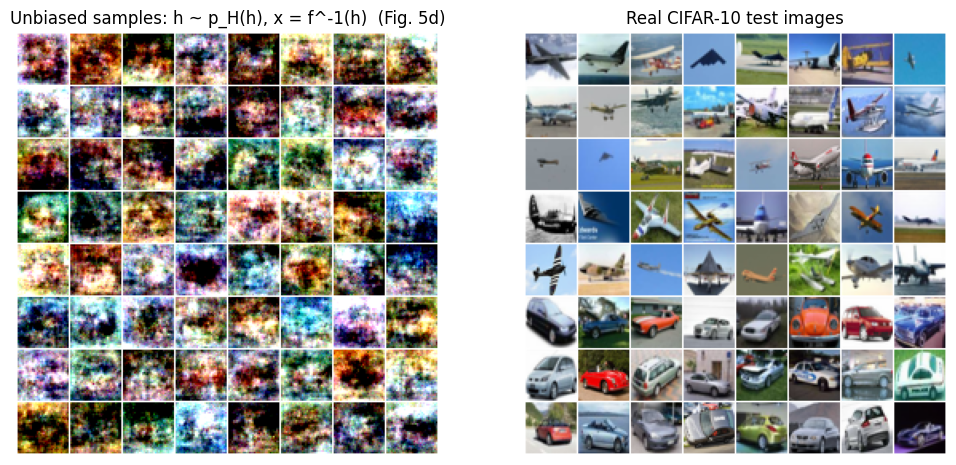

In [21]:

# ---- 5c. Samples (Fig. 5d analogue) vs real images ----
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(tile_rgb(samples, 8, 8))
axes[0].set_title("Unbiased samples: h ~ p_H(h), x = f^-1(h)  (Fig. 5d)")
axes[1].imshow(tile_rgb(test_ds.pixels[:64].numpy() / 128.0 - 1.0, 8, 8))
axes[1].set_title("Real CIFAR-10 test images")
for ax in axes:
    ax.axis("off")
show_fig(fig)

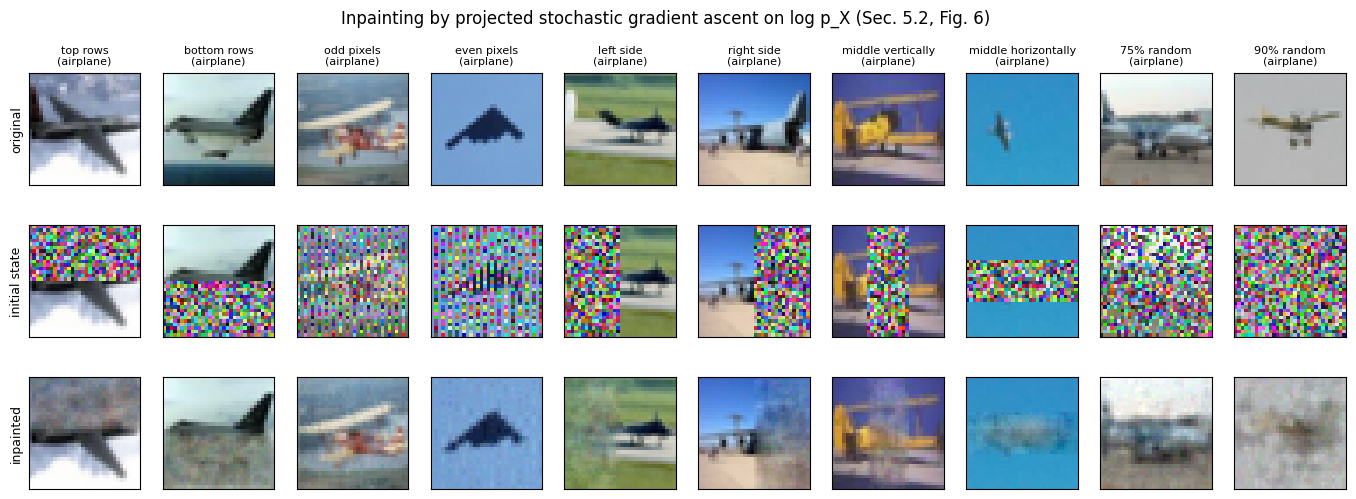

In [20]:

# ---- 5d. Inpainting grid (Fig. 6 analogue) ----
fig, axes = plt.subplots(3, len(MASK_TYPES), figsize=(17, 5.6))
row_names = ["original", "initial state", "inpainted"]
for j, kind in enumerate(MASK_TYPES):
    i = int(np.where(mask_kind_idx == j)[0][0])
    for r, img in enumerate([x_inp_true[i], init_states[i], inpainted[i]]):
        ax = axes[r, j]
        ax.imshow(to_hwc(img.numpy())[0])
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0: ax.set_title(f"{kind}\n({CLASS_NAMES[y_inp[i]]})", fontsize=8)
        if j == 0: ax.set_ylabel(row_names[r], fontsize=9)
fig.suptitle("Inpainting by projected stochastic gradient ascent on log p_X (Sec. 5.2, Fig. 6)")
show_fig(fig)

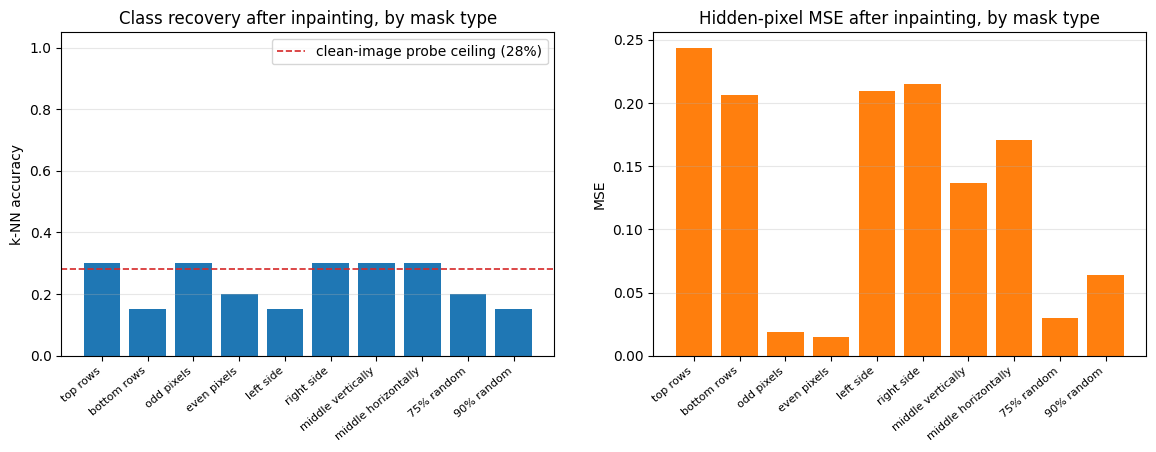

In [19]:

# ---- 5e. Per-mask inpainting quality ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].bar(range(len(MASK_TYPES)), per_mask_acc, color="tab:blue")
axes[0].axhline(acc_clean, color="tab:red", ls="--", lw=1.2,
                label=f"clean-image probe ceiling ({acc_clean:.0%})")
axes[0].set(title="Class recovery after inpainting, by mask type", ylabel="k-NN accuracy",
            ylim=(0, 1.05))
axes[0].legend()
axes[1].bar(range(len(MASK_TYPES)), per_mask_mse, color="tab:orange")
axes[1].set(title="Hidden-pixel MSE after inpainting, by mask type", ylabel="MSE")
for ax in axes:
    ax.set_xticks(range(len(MASK_TYPES)))
    ax.set_xticklabels(MASK_TYPES, rotation=40, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=.3)
show_fig(fig)

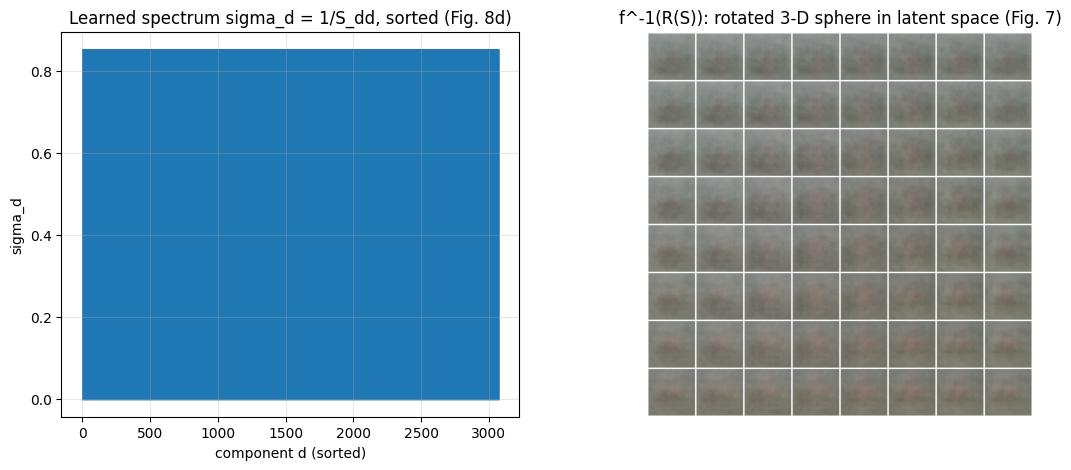

In [18]:

# ---- 5f. Learned spectrum (App. A.2, Fig. 8d) and latent sphere (App. A.1, Fig. 7) ----
sigma = np.sort(torch.exp(-model.s).detach().cpu().numpy())[::-1]   # sigma_d = 1 / S_dd
with torch.no_grad():
    torch.manual_seed(SEED + 3)
    R, _ = torch.linalg.qr(torch.randn(D, 3))          # random rotation of a 3-D sphere
    n_g = 8
    th = torch.linspace(0.15 * math.pi, 0.85 * math.pi, n_g)
    ph = torch.linspace(0, 2 * math.pi, n_g + 1)[:-1]
    TH, PH = torch.meshgrid(th, ph, indexing="ij")
    pts = torch.stack([torch.sin(TH) * torch.cos(PH), torch.sin(TH) * torch.sin(PH),
                       torch.cos(TH)], dim=-1).reshape(-1, 3)
    RADIUS = 5.0   # not specified in the paper; ~3 std of the logistic prior
    sphere_imgs = model.inverse((RADIUS * pts @ R.T).to(device)).clamp(-1, 1).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].fill_between(np.arange(D), sigma, step="mid", color="tab:blue")
axes[0].set(title="Learned spectrum sigma_d = 1/S_dd, sorted (Fig. 8d)",
            xlabel="component d (sorted)", ylabel="sigma_d")
axes[0].grid(alpha=.3)
axes[1].imshow(tile_rgb(sphere_imgs, n_g, n_g))
axes[1].set_title("f^-1(R(S)): rotated 3-D sphere in latent space (Fig. 7)")
axes[1].axis("off")
show_fig(fig)

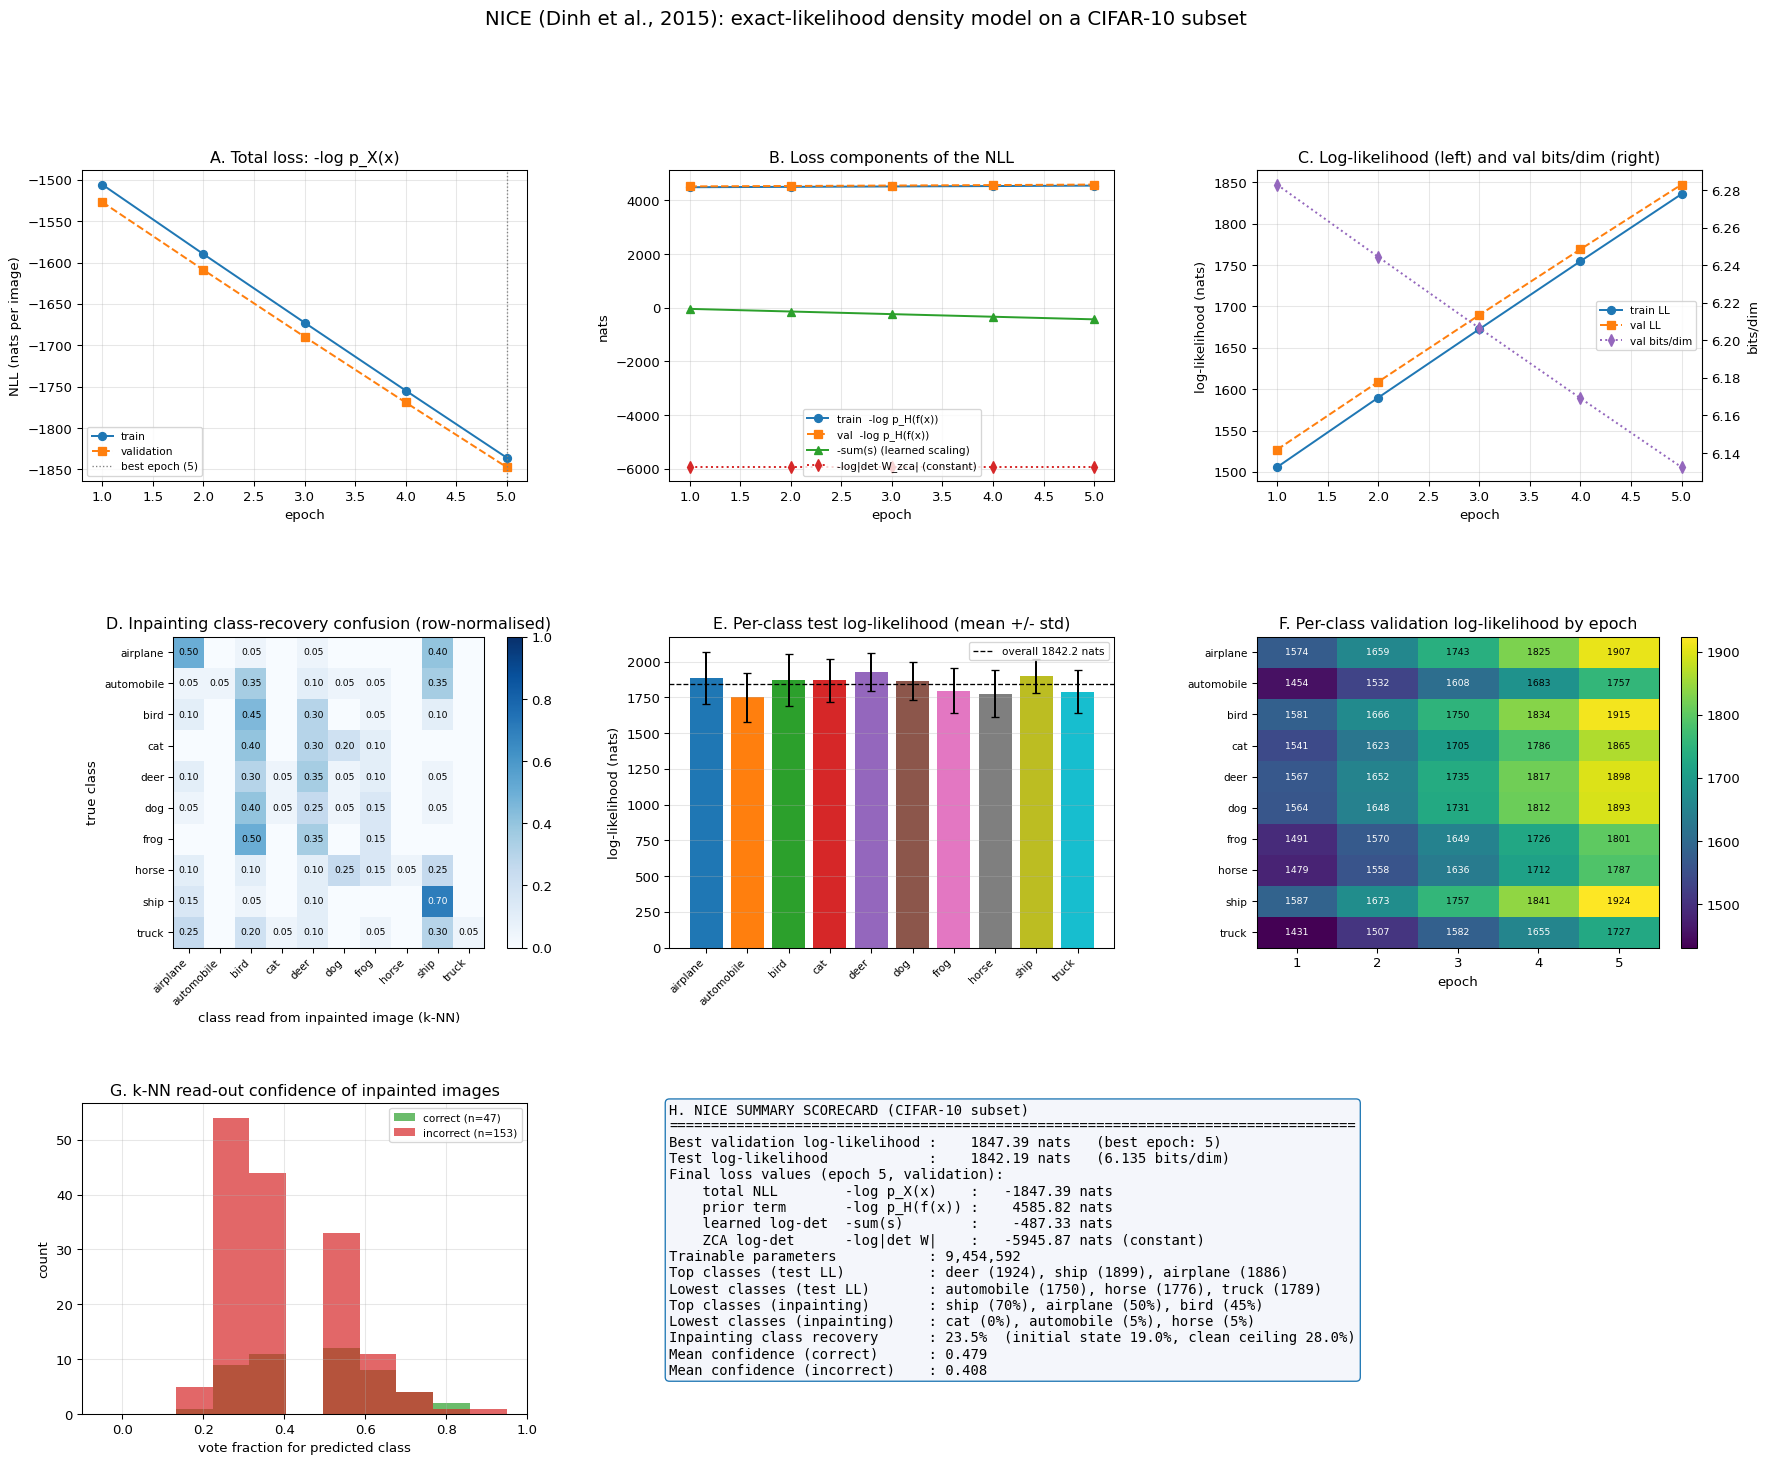

In [17]:

# =============================================================================
# 6. SUMMARY DASHBOARD (final visualisation)
# =============================================================================
# Adaptation of the dashboard template to a density-estimation paper:
#   A  total NLL (the single training objective)
#   B  its components: prior term, learned log-det (-sum s), ZCA constant
#   C  log-likelihood (paper's metric) and bits/dim
#   D  NICE is unsupervised, so there is no classifier confusion matrix. The
#      closest paper-grounded analogue is class-recovery confusion after
#      INPAINTING (Sec. 5.2): true class vs. class read from the completed image.
#   E  per-class test log-likelihood
#   F  per-class validation log-likelihood by epoch
#   G  read-out confidence of inpainted images, correct vs. incorrect
#   H  text scorecard
plt.style.use("default")

fig = plt.figure(figsize=(22, 17))
gs = GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.32)

# ---- Panel A ----
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs, history["train_nll"], "o-", label="train")
axA.plot(epochs, history["val_nll"], "s--", label="validation")
axA.axvline(best_epoch, color="gray", ls=":", lw=1, label=f"best epoch ({best_epoch})")
axA.set(title="A. Total loss: -log p_X(x)", xlabel="epoch", ylabel="NLL (nats per image)")
axA.grid(alpha=.3); axA.legend(fontsize=8)

# ---- Panel B ----
axB = fig.add_subplot(gs[0, 1])
axB.plot(epochs, history["train_prior"], "o-", label="train  -log p_H(f(x))")
axB.plot(epochs, history["val_prior"], "s--", label="val  -log p_H(f(x))")
axB.plot(epochs, history["train_logdet_s"], "^-", label="-sum(s) (learned scaling)")
axB.plot(epochs, history["logdet_zca"], "d:", label="-log|det W_zca| (constant)")
axB.set(title="B. Loss components of the NLL", xlabel="epoch", ylabel="nats")
axB.grid(alpha=.3); axB.legend(fontsize=8)

# ---- Panel C ----
axC = fig.add_subplot(gs[0, 2])
l1 = axC.plot(epochs, history["train_ll"], "o-", color="tab:blue", label="train LL")
l2 = axC.plot(epochs, history["val_ll"], "s--", color="tab:orange", label="val LL")
axC.set(title="C. Log-likelihood (left) and val bits/dim (right)", xlabel="epoch",
        ylabel="log-likelihood (nats)")
axC.grid(alpha=.3)
axC2 = axC.twinx()
l3 = axC2.plot(epochs, history["val_bpd"], "d:", color="tab:purple", label="val bits/dim")
axC2.set_ylabel("bits/dim")
lines = l1 + l2 + l3
axC.legend(lines, [l.get_label() for l in lines], fontsize=8, loc="center right")

# ---- Panel D ----
axD = fig.add_subplot(gs[1, 0])
imD = axD.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
for r in range(N_CLASSES):
    for c in range(N_CLASSES):
        if cm_norm[r, c] > 0:
            axD.text(c, r, f"{cm_norm[r, c]:.2f}", ha="center", va="center", fontsize=7,
                     color="white" if cm_norm[r, c] > 0.5 else "black")
axD.set_xticks(range(N_CLASSES)); axD.set_yticks(range(N_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
axD.set_yticklabels(CLASS_NAMES, fontsize=8)
axD.set(title="D. Inpainting class-recovery confusion (row-normalised)",
        xlabel="class read from inpainted image (k-NN)", ylabel="true class")
fig.colorbar(imD, ax=axD, fraction=0.046)

# ---- Panel E ----
axE = fig.add_subplot(gs[1, 1])
pc_ll = test_eval["per_class_ll"]
pc_std = np.array([test_eval["ll_all"][test_eval["labels"] == k].std() for k in range(N_CLASSES)])
axE.bar(range(N_CLASSES), pc_ll, yerr=pc_std, capsize=3,
        color=plt.cm.tab10(np.arange(N_CLASSES)))
axE.axhline(test_eval["ll"], color="black", ls="--", lw=1,
            label=f"overall {test_eval['ll']:.1f} nats")
axE.set_xticks(range(N_CLASSES))
axE.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
axE.set(title="E. Per-class test log-likelihood (mean +/- std)", ylabel="log-likelihood (nats)")
axE.grid(axis="y", alpha=.3); axE.legend(fontsize=8)

# ---- Panel F ----
axF = fig.add_subplot(gs[1, 2])
heat = np.stack(history["val_class_ll"], axis=1)          # (classes, epochs)
imF = axF.imshow(heat, cmap="viridis", aspect="auto")
mid = (heat.max() + heat.min()) / 2
for r in range(N_CLASSES):
    for c in range(EPOCHS):
        axF.text(c, r, f"{heat[r, c]:.0f}", ha="center", va="center", fontsize=7,
                 color="black" if heat[r, c] > mid else "white")
axF.set_xticks(range(EPOCHS)); axF.set_xticklabels([str(e) for e in epochs])
axF.set_yticks(range(N_CLASSES)); axF.set_yticklabels(CLASS_NAMES, fontsize=8)
axF.set(title="F. Per-class validation log-likelihood by epoch", xlabel="epoch")
fig.colorbar(imF, ax=axF, fraction=0.046)

# ---- Panel G ----
axG = fig.add_subplot(gs[2, 0])
bins = np.linspace(0, 1, KNN_K + 2) - 0.5 / KNN_K
axG.hist(conf_inp[correct], bins=bins, alpha=0.7, color="tab:green",
         label=f"correct (n={int(correct.sum())})")
axG.hist(conf_inp[~correct], bins=bins, alpha=0.7, color="tab:red",
         label=f"incorrect (n={int((~correct).sum())})")
axG.set(title="G. k-NN read-out confidence of inpainted images",
        xlabel="vote fraction for predicted class", ylabel="count")
axG.grid(alpha=.3); axG.legend(fontsize=8)

# ---- Panel H ----
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")
order_ll = np.argsort(pc_ll)
order_inp = np.argsort(per_class_inp_acc)
mean_conf_ok = conf_inp[correct].mean() if correct.any() else float("nan")
mean_conf_bad = conf_inp[~correct].mean() if (~correct).any() else float("nan")
score_lines = [
    "H. NICE SUMMARY SCORECARD (CIFAR-10 subset)",
    "=" * 82,
    f"Best validation log-likelihood : {best_val_ll:10.2f} nats   (best epoch: {best_epoch})",
    f"Test log-likelihood            : {test_eval['ll']:10.2f} nats   ({test_eval['bpd']:.3f} bits/dim)",
    f"Final loss values (epoch {EPOCHS}, validation):",
    f"    total NLL        -log p_X(x)    : {history['val_nll'][-1]:10.2f} nats",
    f"    prior term       -log p_H(f(x)) : {history['val_prior'][-1]:10.2f} nats",
    f"    learned log-det  -sum(s)        : {history['val_logdet_s'][-1]:10.2f} nats",
    f"    ZCA log-det      -log|det W|    : {history['logdet_zca'][-1]:10.2f} nats (constant)",
    f"Trainable parameters           : {n_params:,}",
    "Top classes (test LL)          : " + ", ".join(f"{CLASS_NAMES[k]} ({pc_ll[k]:.0f})" for k in order_ll[::-1][:3]),
    "Lowest classes (test LL)       : " + ", ".join(f"{CLASS_NAMES[k]} ({pc_ll[k]:.0f})" for k in order_ll[:3]),
    "Top classes (inpainting)       : " + ", ".join(f"{CLASS_NAMES[k]} ({per_class_inp_acc[k]:.0%})" for k in order_inp[::-1][:3]),
    "Lowest classes (inpainting)    : " + ", ".join(f"{CLASS_NAMES[k]} ({per_class_inp_acc[k]:.0%})" for k in order_inp[:3]),
    f"Inpainting class recovery      : {acc_inp:.1%}  (initial state {acc_init:.1%}, clean ceiling {acc_clean:.1%})",
    f"Mean confidence (correct)      : {mean_conf_ok:.3f}",
    f"Mean confidence (incorrect)    : {mean_conf_bad:.3f}",
]
axH.text(0.0, 1.0, "\n".join(score_lines), va="top", ha="left", family="monospace",
         fontsize=10.5, transform=axH.transAxes,
         bbox=dict(boxstyle="round", facecolor="#f4f6fb", edgecolor="tab:blue"))

fig.suptitle("NICE (Dinh et al., 2015): exact-likelihood density model on a CIFAR-10 subset",
             fontsize=15)

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=95, bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Related Work: References from Section 4 ("Related Methods")

The table covers the 19 works cited in Section 4 ("Related Methods"), the paper's related-work discussion, in the order the paper discusses them. Venues are given as they appear in the paper's reference list.

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Salakhutdinov, R., & Hinton, G. | 2009 | Deep Boltzmann machines | *Proc. AISTATS*, Vol. 5, pp. 448–455 | Representative undirected generative model. Its MCMC-based training and sampling and its intractable log-likelihood are the limitations NICE avoids. |
| Salakhutdinov, R., & Murray, I. | 2008 | On the quantitative analysis of deep belief networks | *Proc. ICML (ICML'08)*, Vol. 25, pp. 872–879 | Introduces AIS for estimating likelihoods of undirected models. NICE replaces such estimates with an exact log-likelihood. |
| Grosse, R., Maddison, C., & Salakhutdinov, R. | 2013 | Annealing between distributions by averaging moments | *ICML 2013* | Shows that AIS can give overly optimistic likelihood estimates, which motivates NICE's exact, tractable evaluation. |
| Kingma, D. P., & Welling, M. | 2014 | Auto-encoding variational Bayes | *Proc. ICLR* | The VAE: an approximate-inference directed model trained on a lower bound. NICE is presented as its exact-likelihood counterpart, and Appendix C recasts the VAE as a NICE model. |
| Rezende, D. J., Mohamed, S., & Wierstra, D. | 2014 | Stochastic backpropagation and approximate inference in deep generative models | Technical report, arXiv:1401.4082 | A concurrent variational auto-encoder formulation. Its stochastic encoder and imperfect decoder contrast with NICE's deterministic, exactly invertible pair. |
| Mnih, A., & Gregor, K. | 2014 | Neural variational inference and learning in belief networks | *ICML 2014* | A variational training method for directed models, cited among approaches whose lower-bound objective NICE replaces with the exact likelihood. |
| Gregor, K., Danihelka, I., Mnih, A., Blundell, C., & Wierstra, D. | 2014 | Deep autoregressive networks | *ICML 2014* | A variational directed model with autoregressive structure, cited as part of the VAE family that NICE contrasts with. |
| Bengio, Y. | 2014 | How auto-encoders could provide credit assignment in deep networks via target propagation | Technical report, arXiv:1407.7906 | Supplies the view of an invertible transform and its inverse as a perfect auto-encoder pair, which NICE uses to link its criterion to the variational objective. |
| Hyvärinen, A., & Oja, E. | 2000 | Independent component analysis: Algorithms and applications | *Neural Networks*, 13(4), 411–430 | Linear ICA, NICE's namesake. Its maximum-likelihood form learns only orthogonal transforms and needs costly orthogonalization; NICE extends the goal to non-linear transforms. |
| Bengio, Y. | 1991 | Artificial neural networks and their application to sequence recognition | PhD thesis, McGill University | Early proposal to learn richer, neural-network transformations for density modelling. It lacked the structure for tractable inference and optimization, which coupling layers provide. |
| Chen, S. S., & Gopinath, R. A. | 2000 | Gaussianization | Not specified in reference list | Learns a layered transformation to a Gaussian, but greedily and without tractable sampling. NICE trains all layers jointly and samples exactly. |
| Rippel, O., & Adams, R. P. | 2013 | High-dimensional probability estimation with deep density models | arXiv:1302.5125 | Revisits learned transformations, but without a bijectivity constraint it relies on a regularized auto-encoder proxy. NICE enforces bijectivity to optimize the likelihood directly. |
| Hyvärinen, A., & Pajunen, P. | 1999 | Nonlinear independent component analysis: Existence and uniqueness results | *Neural Networks*, 12(3), 429–439 | Theoretical foundation for non-linear ICA, the problem NICE addresses with a tractable, learnable non-linear bijection. |
| Roberts, S., & Everson, R. | 2001 | Independent component analysis: Principles and practice | Cambridge University Press | Cited for ensemble-learning (variational) approaches to non-linear ICA, which optimize a lower bound rather than NICE's exact likelihood. |
| Lappalainen, H., Giannakopoulos, X., Honkela, A., & Karhunen, J. | 2000 | Nonlinear independent component analysis using ensemble learning: Experiments and discussion | *Proc. ICA* | Applies the variational lower bound to non-linear ICA. Cited as a principled but approximate alternative to NICE's exact criterion. |
| Dayan, P., Hinton, G. E., Neal, R., & Zemel, R. | 1995 | The Helmholtz machine | *Neural Computation*, 7, 889–904 | The original recognition–generation architecture underlying VAEs. NICE likewise pairs an encoder with a decoder, but its decoder exactly inverts its encoder. |
| Goodfellow, I. J., et al. | 2014 | Generative adversarial networks | Technical report, arXiv:1406.2661 | Also transforms a simple factorial distribution into the data distribution, but without an encoder or a tractable likelihood. Contrasted with NICE's invertible, likelihood-based training. |
| Bengio, Y., & Bengio, S. | 2000 | Modeling high-dimensional discrete data with multi-layer neural networks | *Advances in NIPS 12 (NIPS'99)*, pp. 400–406, MIT Press | Introduces neural autoregressive density models, which share NICE's triangular structure as the source of tractability. |
| Larochelle, H., & Murray, I. | 2011 | The neural autoregressive distribution estimator | *Proc. AISTATS 2011*, JMLR W&CP Vol. 15 | NADE has a strictly triangular dependency structure but samples sequentially and cannot be parallelized. A one-coupling-layer NICE is a two-block NADE with parallel sampling. |

**Scope note:** Works cited only in the introduction (e.g., Bengio, 2009; Ozair & Bengio, 2014; Bengio et al., 2013), the experiments (e.g., Tang et al., 2012; Uria et al., 2013; dataset papers), or the conclusion (Cohen & Welling, 2014) are excluded, since they fall outside the related-work discussion.

**Citation note:** Grosse et al. (2013) is listed as ICML in the paper's reference list, though it is commonly cited as appearing at NIPS 2013. Verify before formal citation.